# Классификация болезни Паркинсона по дистанциям landmarks — wide-формат
## Ablation Study: вклад групп признаков + полный пайплайн

**Упражнение:** нахмуривание бровей.  
**Данные.** 150 пациентов (123 PD / 27 Healthy), 256 наблюдений. В wide-формате каждая строка — один (`Patient`, `r`). 25 dist_ пар × 13 агрегатов = 325 признаков дистанций. 309 треугольников × 6 агрегатов площади = 1854 признака площадей.  
**Кросс-валидация.** `StratifiedGroupKFold(n_splits=5)` по `Patient`. Пациент не попадает одновременно в train и test.  
**Пайплайн.** `CorrelationFilter(0.95) → StandardScaler → Model` (LR / RF / XGB / LGBM / SVM).

## Версии библиотек

In [4]:
import sklearn, xgboost, lightgbm, umap, imblearn
print(f'scikit-learn: {sklearn.__version__}')
print(f'xgboost:      {xgboost.__version__}')
print(f'lightgbm:     {lightgbm.__version__}')
print(f'umap-learn:   {umap.__version__}')
print(f'imbalanced:   {imblearn.__version__}')

scikit-learn: 1.7.2
xgboost:      3.2.0
lightgbm:     4.6.0
umap-learn:   0.5.12
imbalanced:   0.14.1


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 13
import seaborn as sns
from scipy import stats
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedGroupKFold, cross_validate
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             roc_curve, roc_auc_score)
from sklearn.metrics import make_scorer
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from umap import UMAP

import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='lightgbm')
warnings.filterwarnings('ignore', message='X does not have valid feature names')

RANDOM_STATE = 42
DURATION_COL = 'exercise_duration'
n_components_list = [2, 5, 10, 20]
print('Импорты выполнены.')

Импорты выполнены.


---
## ══ БЛОК 1 — Данные и пайплайн ══

## 1. Загрузка данных

In [8]:
df = pd.read_csv('data_ML_frown_pivot_dinamika_areas.csv')
df = df.drop(columns=['num_frames'])

y      = df['label']
groups = df['id']

print(f'Shape: {df.shape}')
print(f'Баланс наблюдений: PD={int((y==1).sum())}, Healthy={int((y==0).sum())}')
print(f'Баланс пациентов:  PD={df[df.label==1]["id"].nunique()}, Healthy={df[df.label==0]["id"].nunique()}')
print(f'Среднее retake — PD: {df[df.label==1].groupby("id").size().mean():.2f}, '
      f'Healthy: {df[df.label==0].groupby("id").size().mean():.2f}')

Shape: (256, 2183)
Баланс наблюдений: PD=157, Healthy=99
Баланс пациентов:  PD=123, Healthy=27
Среднее retake — PD: 1.28, Healthy: 3.67


In [9]:
AGG_GROUPS = {
    'geometry': ['min_norm', 'max_norm', 'mean_norm', 'median_norm', 'std_norm'],
    'velocity': ['max_vel_norm', 'mean_vel_norm', 'std_vel_norm'],
    'accel':    ['max_acc_norm', 'std_acc_norm'],
    'angle':    ['mean_angle', 'std_angle', 'range_angle'],
}

feat_geom = [c for c in df.columns if c.startswith('dist_')
             and any(c.endswith(f'_{a}') for a in AGG_GROUPS['geometry'])]
feat_vel  = [c for c in df.columns if c.startswith('dist_')
             and any(c.endswith(f'_{a}') for a in AGG_GROUPS['velocity'])]
feat_acc  = [c for c in df.columns if c.startswith('dist_')
             and any(c.endswith(f'_{a}') for a in AGG_GROUPS['accel'])]
feat_ang  = [c for c in df.columns if c.startswith('dist_')
             and any(c.endswith(f'_{a}') for a in AGG_GROUPS['angle'])]
feat_area = [c for c in df.columns if c.startswith('area_')]
feat_dyn  = feat_vel + feat_acc
feat_all_dist = [c for c in df.columns if c.startswith('dist_')]

print('Доступные группы признаков:')
print(f'  Геометрия (амплитуда) : {len(feat_geom):3d} фич')
print(f'  Скорость              : {len(feat_vel):3d} фич')
print(f'  Ускорение             : {len(feat_acc):3d} фич')
print(f'  Углы                  : {len(feat_ang):3d} фич')
print(f'  Треугольные площади   : {len(feat_area):3d} фич  (отдельный датасет)')
print(f'  Итого dist_           : {len(feat_all_dist):3d} фич')
print()

# feat_no_dur / feat_cols — для совместимости с пайплайном (геометрический baseline)
feat_no_dur = feat_geom
feat_cols   = feat_geom + ([DURATION_COL] if DURATION_COL in df.columns else [])

Доступные группы признаков:
  Геометрия (амплитуда) : 125 фич
  Скорость              :  75 фич
  Ускорение             :  50 фич
  Углы                  :  75 фич
  Треугольные площади   : 1854 фич  (отдельный датасет)
  Итого dist_           : 325 фич



## 2. Статистический обзор признаков

Критерий Манна-Уитни (U-тест) применяется ко **всем** `dist_`-признакам (геометрия + динамика + углы — итого {feat_all_dist} фич).  
При множественных сравнениях применяется поправка Бонферрони: `α_adj = 0.05 / N_features`.  
Площадные признаки (`area_`) анализируются в отдельном блокноте.

In [11]:
alpha = 0.05
n_features = len(feat_all_dist)
alpha_bonf = alpha / n_features

pvals = {}; stats_u = {}
for c in feat_all_dist:
    x_pd = df.loc[df['label']==1, c].dropna()
    x_hc = df.loc[df['label']==0, c].dropna()
    u, p = stats.mannwhitneyu(x_pd, x_hc, alternative='two-sided')
    pvals[c] = p; stats_u[c] = u

mw_df = pd.DataFrame({'feature': list(pvals.keys()), 'p_value': list(pvals.values())})
mw_df = mw_df.sort_values('p_value').reset_index(drop=True)
mw_df['significant_raw']  = mw_df['p_value'] < alpha
mw_df['significant_bonf'] = mw_df['p_value'] < alpha_bonf
mw_df['neg_log10_p']      = -np.log10(mw_df['p_value'].clip(lower=1e-300))
mw_df['group'] = mw_df['feature'].apply(
    lambda c: 'velocity' if '_vel_norm' in c else
              'accel'    if '_acc_norm' in c else
              'angle'    if '_angle' in c else 'geometry')

print(f'Всего dist_ признаков:            {n_features}')
print(f'Порог α (без поправки):           {alpha:.4f}')
print(f'Порог α (Bonferroni):             {alpha_bonf:.2e}')
print()
print(f'Значимых без поправки (p < 0.05): {int(mw_df["significant_raw"].sum())}')
print(f'Значимых после Bonferroni:        {int(mw_df["significant_bonf"].sum())}')
print()
print('По группам (без поправки):')
for g in ['geometry', 'velocity', 'accel', 'angle']:
    sub = mw_df[mw_df['group'] == g]
    print(f'  {g:10s}: {int(sub["significant_raw"].sum())} / {len(sub)}')

Всего dist_ признаков:            325
Порог α (без поправки):           0.0500
Порог α (Bonferroni):             1.54e-04

Значимых без поправки (p < 0.05): 233
Значимых после Bonferroni:        110

По группам (без поправки):
  geometry  : 64 / 125
  velocity  : 74 / 75
  accel     : 41 / 50
  angle     : 54 / 75


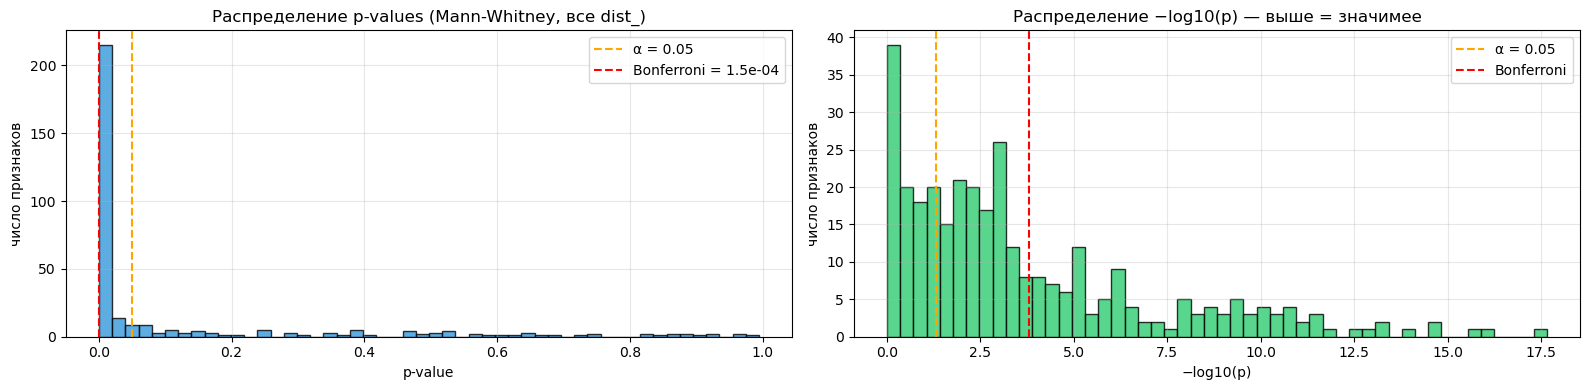

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

axes[0].hist(mw_df['p_value'], bins=50, color='#3498db', alpha=0.8, edgecolor='black')
axes[0].axvline(alpha, color='orange', ls='--', label=f'α = {alpha}')
axes[0].axvline(alpha_bonf, color='red', ls='--', label=f'Bonferroni = {alpha_bonf:.1e}')
axes[0].set_xlabel('p-value'); axes[0].set_ylabel('число признаков')
axes[0].set_title('Распределение p-values (Mann-Whitney, все dist_)')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].hist(mw_df['neg_log10_p'], bins=50, color='#2ecc71', alpha=0.8, edgecolor='black')
axes[1].axvline(-np.log10(alpha), color='orange', ls='--', label=f'α = {alpha}')
axes[1].axvline(-np.log10(alpha_bonf), color='red', ls='--', label='Bonferroni')
axes[1].set_xlabel('−log10(p)'); axes[1].set_ylabel('число признаков')
axes[1].set_title('Распределение −log10(p) — выше = значимее')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

In [13]:
top20 = mw_df.head(20).copy()
top20['p_value'] = top20['p_value'].apply(lambda p: f'{p:.2e}')
display(top20[['feature', 'group', 'p_value', 'significant_bonf']])

,feature,group,p_value,significant_bonf
0,dist_65_109_mean_vel_norm,velocity,2.21e-18,True
1,dist_65_109_std_vel_norm,velocity,7.30e-17,True
2,dist_55_10_mean_vel_norm,velocity,1.45e-16,True
3,dist_55_10_std_vel_norm,velocity,2.08e-15,True
4,dist_52_151_mean_vel_norm,velocity,2.87e-15,True
5,dist_295_338_mean_vel_norm,velocity,7.63e-15,True
6,dist_295_338_std_vel_norm,velocity,4.07e-14,True
7,dist_52_151_std_vel_norm,velocity,4.91e-14,True
8,dist_285_10_mean_vel_norm,velocity,1.80e-13,True
9,dist_282_168_mean_vel_norm,velocity,4.22e-13,True


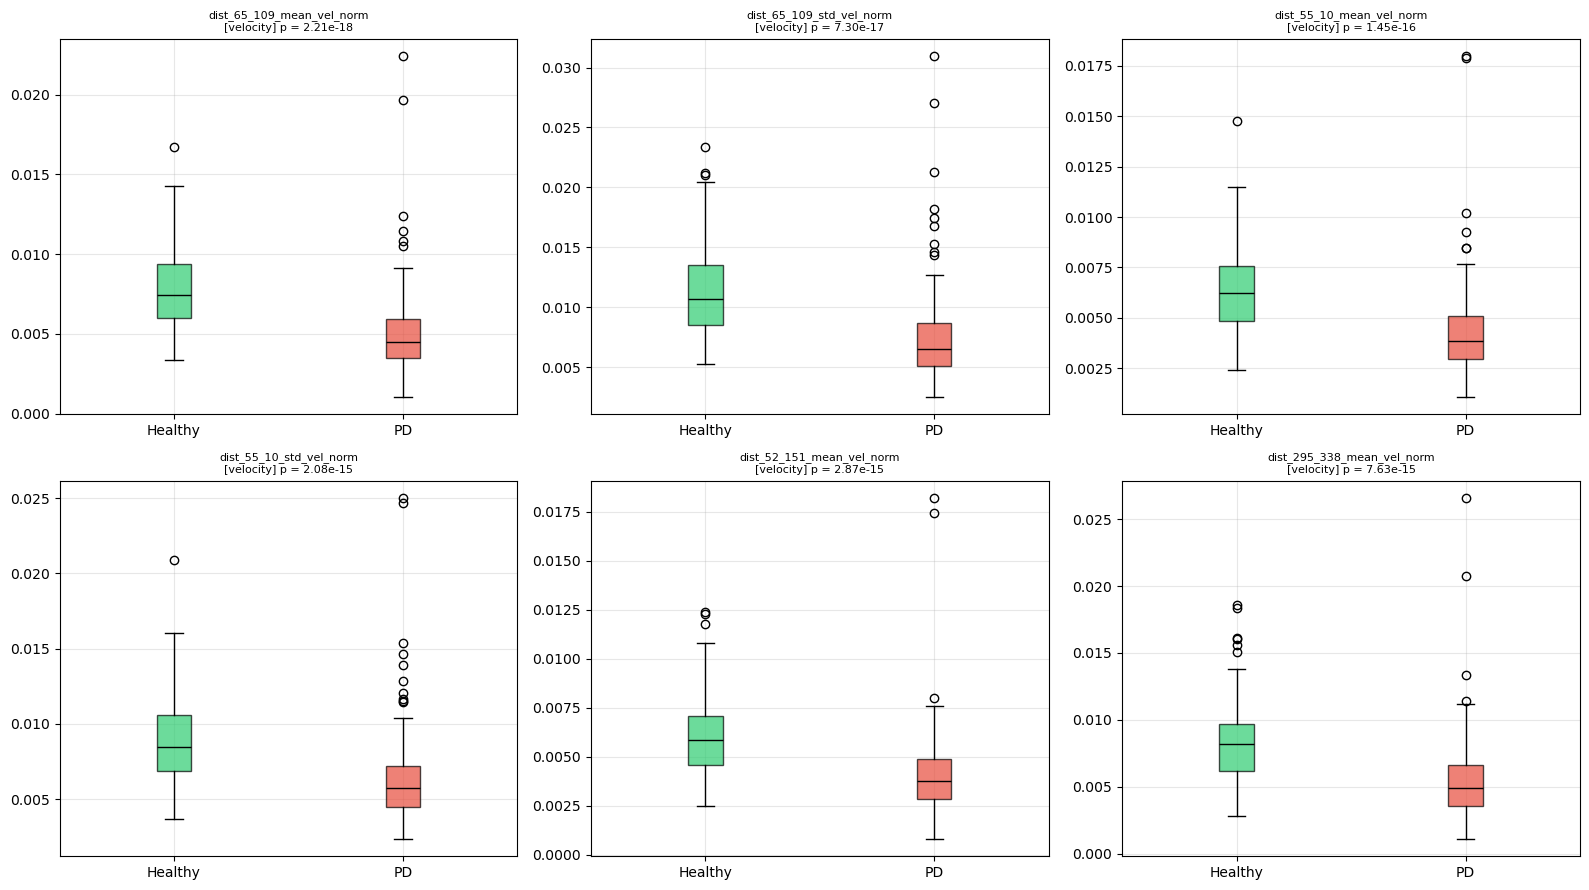

In [14]:
top6 = mw_df.head(6)['feature'].tolist()
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for i, feat in enumerate(top6):
    ax = axes[i // 3, i % 3]
    data_pd = df.loc[df['label']==1, feat]
    data_hc = df.loc[df['label']==0, feat]
    bp = ax.boxplot([data_hc, data_pd], labels=['Healthy', 'PD'], patch_artist=True,
                    boxprops=dict(alpha=0.7), medianprops=dict(color='black'))
    bp['boxes'][0].set_facecolor('#2ecc71')
    bp['boxes'][1].set_facecolor('#e74c3c')
    p = mw_df[mw_df['feature']==feat]['p_value'].values[0]
    grp = mw_df[mw_df['feature']==feat]['group'].values[0]
    ax.set_title(f'{feat}\n[{grp}] p = {p:.2e}', fontsize=13)
    ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 3. Функции пайплайна и трансформеры

- `CorrelationFilter` — удаляет признаки с корреляцией выше порога (0.95). Фитится только на train-фолде.
- `DirectionalFeatureSelector` — отбор min/max по направлению движения (раздел 19).
- `build_models` — пять моделей с `class_weight='balanced'`.
- `run_all` — прогоняет все модели через `CorrelationFilter → StandardScaler → Model`, 5-fold CV.

In [16]:
class CorrelationFilter(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.95):
        self.threshold = threshold
    def fit(self, X, y=None):
        X_df = X if isinstance(X, pd.DataFrame) else pd.DataFrame(X)
        corr = X_df.corr().abs()
        upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        cols = list(upper.columns)
        to_drop = set(c for c in cols if any(upper[c] > self.threshold))
        self.keep_mask_ = np.array([c not in to_drop for c in cols])
        self.feature_names_in_list_ = list(cols)
        return self
    def transform(self, X):
        X_arr = X.values if isinstance(X, pd.DataFrame) else X
        return X_arr[:, self.keep_mask_]


class DirectionalFeatureSelector(BaseEstimator, TransformerMixin):
    def __init__(self, eps=0.02, mode='directional'):
        self.eps = eps; self.mode = mode
    def fit(self, X, y=None):
        assert isinstance(X, pd.DataFrame), 'Требуется DataFrame с именами колонок'
        self.feature_names_in_ = list(X.columns)
        if self.mode == 'none':
            self.keep_columns_ = list(X.columns); return self
        mean_cols = [c for c in X.columns if c.startswith('dist_') and c.endswith('_mean_norm')]
        pair_means = {c.replace('_mean_norm', ''): X[c].mean() for c in mean_cols}
        keep = []
        for col in X.columns:
            if not col.startswith('dist_'):
                keep.append(col); continue
            if col.endswith('_max_norm'):
                if self.mode == 'minimal': continue
                pair = col.replace('_max_norm', '')
                if pair_means.get(pair, 1.0) > 1 + self.eps: keep.append(col)
            elif col.endswith('_min_norm'):
                if self.mode == 'minimal': continue
                pair = col.replace('_min_norm', '')
                if pair_means.get(pair, 1.0) < 1 - self.eps: keep.append(col)
            else:
                keep.append(col)
        self.keep_columns_ = keep; return self
    def transform(self, X):
        if isinstance(X, pd.DataFrame): return X[self.keep_columns_]
        idx = [self.feature_names_in_.index(c) for c in self.keep_columns_]
        return X[:, idx]


def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp)

scoring = {
    'balanced_accuracy': 'balanced_accuracy',
    'accuracy': 'accuracy',
    'f1': 'f1',
    'roc_auc': 'roc_auc',
    'sensitivity': 'recall',
    'specificity': make_scorer(specificity_score),
}

def build_models(y):
    return {
        'LR':   LogisticRegression(max_iter=5000, class_weight='balanced', random_state=RANDOM_STATE),
        'RF':   RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                       random_state=RANDOM_STATE, n_jobs=-1),
        'XGB':  XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.1,
                              scale_pos_weight=(y==0).sum()/(y==1).sum(),
                              random_state=RANDOM_STATE, eval_metric='logloss'),
        'LGBM': LGBMClassifier(n_estimators=300, max_depth=4, learning_rate=0.1,
                               class_weight='balanced', random_state=RANDOM_STATE, verbose=-1),
        'SVM':  SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=RANDOM_STATE),
    }

def run_all(X, y, groups):
    cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    models = build_models(y)
    res = {}
    for name, model in models.items():
        pipe = Pipeline([
            ('corr',   CorrelationFilter(threshold=0.95)),
            ('scaler', StandardScaler()),
            ('model',  model),
        ])
        cvr = cross_validate(pipe, X, y, groups=groups, cv=cv,
                             scoring=scoring, return_train_score=False)
        res[name] = {k: (np.mean(cvr[f'test_{k}']), np.std(cvr[f'test_{k}'])) for k in scoring}
    return res

model_names = ['LR', 'RF', 'XGB', 'LGBM', 'SVM']
colors_m = {'LR':'#3498db','RF':'#2ecc71','XGB':'#e74c3c','LGBM':'#f39c12','SVM':'#9b59b6'}
metrics_list  = ['balanced_accuracy','accuracy','f1','roc_auc','sensitivity','specificity']
metric_labels = ['Bal.Acc','Accuracy','F1','ROC-AUC','Sensitivity','Specificity']
print('Функции определены.')

Функции определены.


## 4. Проверка корректности CV-разбиения

In [18]:
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
X_check = df[feat_no_dur]
print('Пациенты НЕ пересекаются между train и test:\n')
for i, (tr, te) in enumerate(cv.split(X_check, y, groups)):
    tp, ep = set(groups.iloc[tr]), set(groups.iloc[te])
    print(f'  Fold {i+1}: train={len(tr)} ({len(tp)} пац.), '
          f'test={len(te)} ({len(ep)} пац.), overlap={len(tp & ep)}')

Пациенты НЕ пересекаются между train и test:

  Fold 1: train=209 (120 пац.), test=47 (30 пац.), overlap=0
  Fold 2: train=202 (120 пац.), test=54 (30 пац.), overlap=0
  Fold 3: train=213 (121 пац.), test=43 (29 пац.), overlap=0
  Fold 4: train=201 (120 пац.), test=55 (30 пац.), overlap=0
  Fold 5: train=199 (119 пац.), test=57 (31 пац.), overlap=0


---
## ══ БЛОК 2 — Вклад групп признаков ══

Каждая группа прогоняется через одинаковый пайплайн:  
`CorrelationFilter → StandardScaler → Model` (5-fold StratifiedGroupKFold, groups=пациент).  
Метрика сравнения — **ROC-AUC** (среднее ± std по фолдам).  
В конце блока — сводная таблица и ROC-кривые лучшей конфигурации.

## 5. Геометрические признаки (baseline)

Амплитудные агрегаты `min/max/mean/median/std` по дистанциям — основа прошлых итераций.  
310 признаков, без клинических параметров.

In [21]:
print(f'Геометрия: {len(feat_geom)} признаков')
print('Обучаю...')
res_no = run_all(df[feat_geom], y, groups)
print('Готово.')

Геометрия: 125 признаков
Обучаю...
Готово.


In [22]:
rows = []
for mn in model_names:
    r = res_no[mn]
    rows.append({'Model': mn,
        'Bal.Acc':  f'{r["balanced_accuracy"][0]:.3f}±{r["balanced_accuracy"][1]:.3f}',
        'Accuracy': f'{r["accuracy"][0]:.3f}±{r["accuracy"][1]:.3f}',
        'F1':       f'{r["f1"][0]:.3f}±{r["f1"][1]:.3f}',
        'ROC-AUC':  f'{r["roc_auc"][0]:.3f}±{r["roc_auc"][1]:.3f}',
        'Sens':     f'{r["sensitivity"][0]:.3f}±{r["sensitivity"][1]:.3f}',
        'Spec':     f'{r["specificity"][0]:.3f}±{r["specificity"][1]:.3f}',
    })
display(pd.DataFrame(rows))

,Model,Bal.Acc,Accuracy,F1,ROC-AUC,Sens,Spec
0,LR,0.485±0.047,0.525±0.044,0.634±0.046,0.512±0.067,0.669±0.050,0.302±0.115
1,RF,0.559±0.053,0.614±0.060,0.721±0.054,0.634±0.059,0.819±0.105,0.298±0.083
2,XGB,0.534±0.079,0.586±0.087,0.685±0.087,0.590±0.086,0.743±0.113,0.324±0.085
3,LGBM,0.512±0.050,0.567±0.070,0.674±0.076,0.570±0.081,0.738±0.103,0.286±0.048
4,SVM,0.560±0.064,0.594±0.058,0.681±0.055,0.635±0.058,0.705±0.068,0.414±0.123


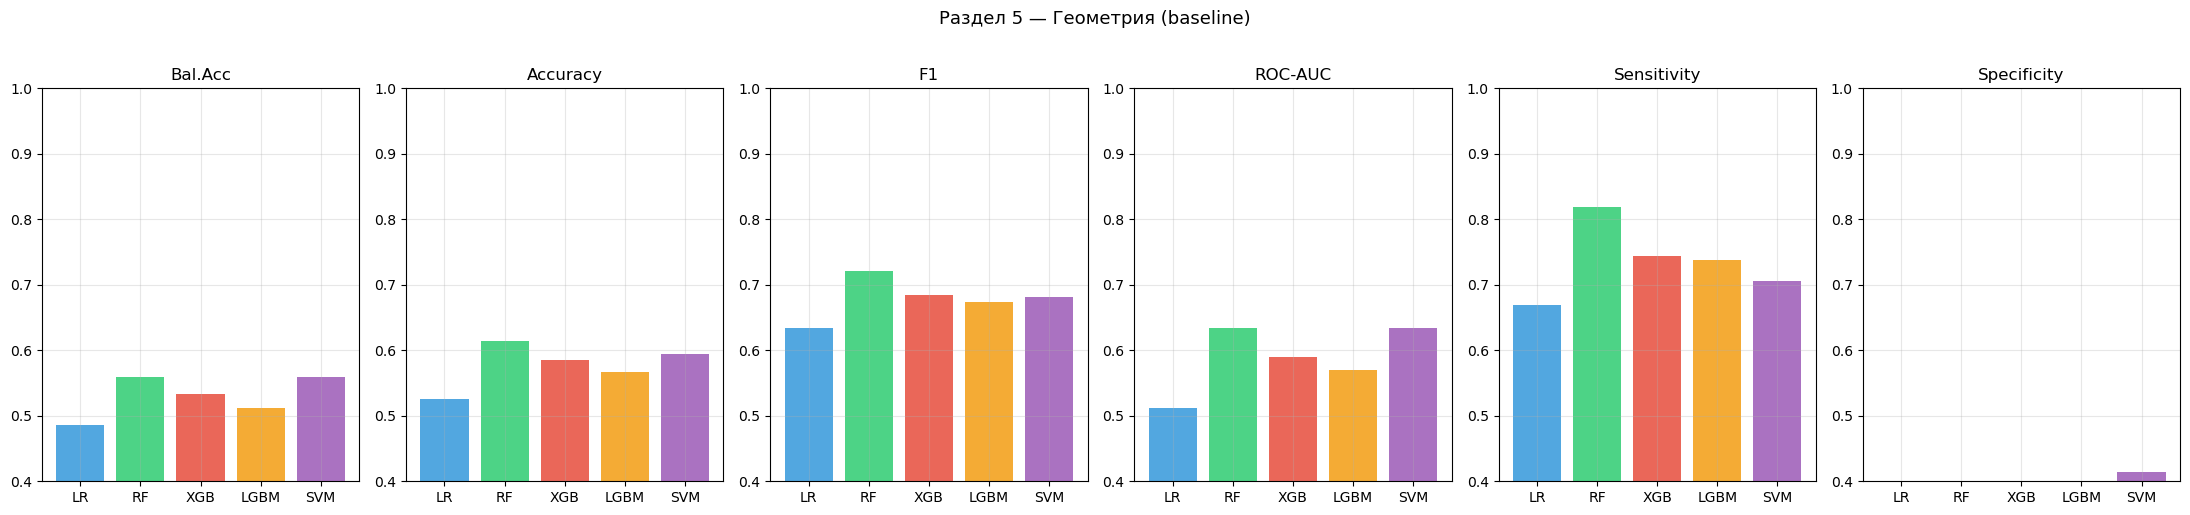

In [23]:
fig, axes = plt.subplots(1, len(metrics_list), figsize=(22, 5))
fig.suptitle('Раздел 5 — Геометрия (baseline)', fontsize=13, y=1.02)
for i, (metric, label) in enumerate(zip(metrics_list, metric_labels)):
    vals = [res_no[m][metric][0] for m in model_names]
    axes[i].bar(model_names, vals, color=[colors_m[m] for m in model_names],
                alpha=0.85, capsize=4)
    axes[i].set_title(label); axes[i].set_ylim(0.4, 1.0); axes[i].grid(alpha=0.3)
plt.tight_layout(); plt.show()

### Heatmap: метрики × модели

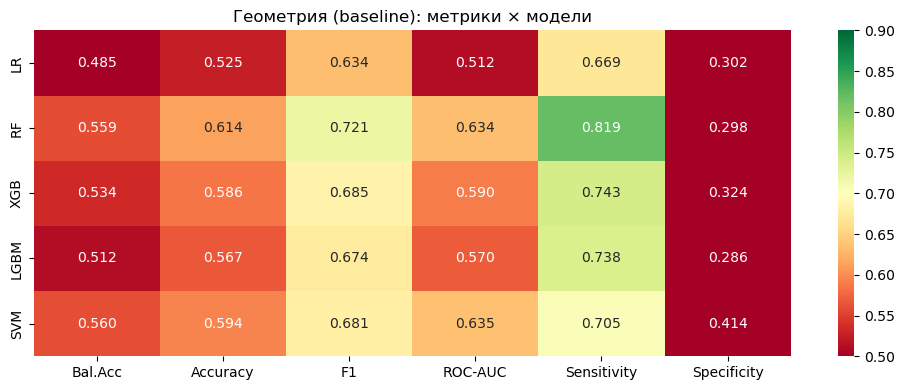

In [25]:
hm = np.zeros((len(model_names), len(metrics_list)))
for i, mn in enumerate(model_names):
    for j, met in enumerate(metrics_list):
        hm[i,j] = res_no[mn][met][0]
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(hm, xticklabels=metric_labels, yticklabels=model_names,
            annot=True, fmt='.3f', cmap='RdYlGn', vmin=0.5, vmax=0.9, ax=ax)
ax.set_title('Геометрия (baseline): метрики × модели')
plt.tight_layout(); plt.show()

## 6. Динамика — скорость и ускорение

**Мотивация:** брадикинезия при ПД — замедление движений.  
Скорость (`max/mean/std_vel_norm`) фиксирует пиковую и среднюю скорость.  
Ускорение (`max/std_acc_norm`) — рывковость и ригидность.  
Производные вычислены по сглаженному ряду (Savitzky-Golay, window=5) в preprocessing.

In [27]:
print(f'Динамика: скорость {len(feat_vel)} + ускорение {len(feat_acc)} = {len(feat_dyn)} признаков')
print('Обучаю...')
res_dyn = run_all(df[feat_dyn], y, groups)
print('Готово.')

Динамика: скорость 75 + ускорение 50 = 125 признаков
Обучаю...
Готово.


,Model,ROC-AUC (дин),ROC-AUC (геом),ΔAUC,Bal.Acc,Sens,Spec
0,LR,0.765±0.117,0.512,+0.253,0.719,0.776,0.662
1,RF,0.802±0.099,0.634,+0.168,0.686,0.866,0.506
2,XGB,0.789±0.082,0.590,+0.199,0.687,0.822,0.552
3,LGBM,0.785±0.082,0.570,+0.215,0.671,0.802,0.540
4,SVM,0.788±0.082,0.635,+0.153,0.684,0.783,0.586


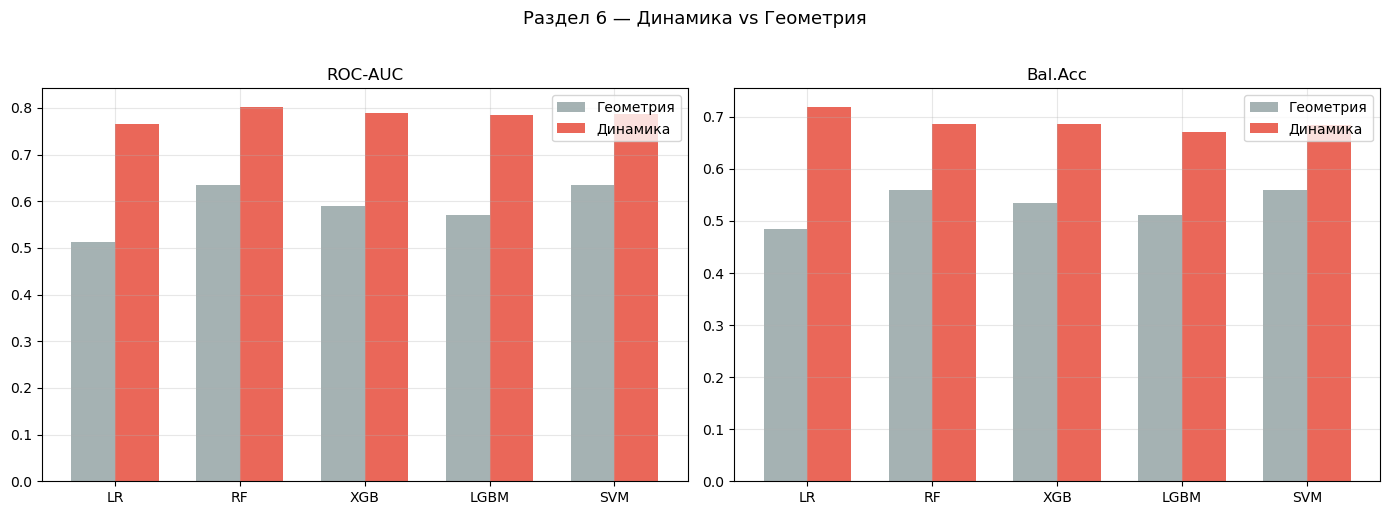

In [28]:
rows = []
for mn in model_names:
    r = res_dyn[mn]; r0 = res_no[mn]
    rows.append({'Model': mn,
        'ROC-AUC (дин)':  f'{r["roc_auc"][0]:.3f}±{r["roc_auc"][1]:.3f}',
        'ROC-AUC (геом)': f'{r0["roc_auc"][0]:.3f}',
        'ΔAUC':           f'{r["roc_auc"][0]-r0["roc_auc"][0]:+.3f}',
        'Bal.Acc':        f'{r["balanced_accuracy"][0]:.3f}',
        'Sens':           f'{r["sensitivity"][0]:.3f}',
        'Spec':           f'{r["specificity"][0]:.3f}',
    })
display(pd.DataFrame(rows))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Раздел 6 — Динамика vs Геометрия', fontsize=13, y=1.02)
x = np.arange(len(model_names)); w = 0.35
for ax_i, (metric, label) in enumerate([('roc_auc','ROC-AUC'),('balanced_accuracy','Bal.Acc')]):
    v0 = [res_no[m][metric][0] for m in model_names]
    vd = [res_dyn[m][metric][0] for m in model_names]
    axes[ax_i].bar(x-w/2, v0, w, label='Геометрия', color='#95a5a6', alpha=0.85)
    axes[ax_i].bar(x+w/2, vd, w, label='Динамика',  color='#e74c3c', alpha=0.85)
    axes[ax_i].set_xticks(x); axes[ax_i].set_xticklabels(model_names)
    axes[ax_i].set_title(label); axes[ax_i].legend(); axes[ax_i].grid(alpha=0.3)
plt.tight_layout(); plt.show()

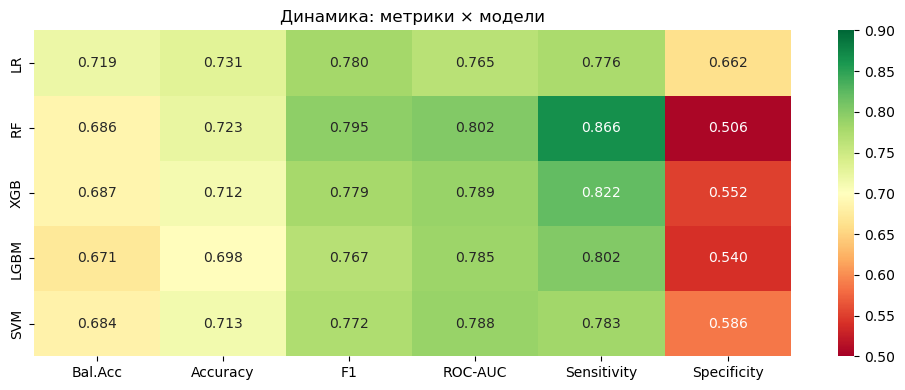

In [29]:
hm6 = np.zeros((len(model_names), len(metrics_list)))
for i, mn in enumerate(model_names):
    for j, met in enumerate(metrics_list): hm6[i,j] = res_dyn[mn][met][0]
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(hm6, xticklabels=metric_labels, yticklabels=model_names,
            annot=True, fmt='.3f', cmap='RdYlGn', vmin=0.5, vmax=0.9, ax=ax)
ax.set_title('Динамика: метрики × модели')
plt.tight_layout(); plt.show()

## 7. Геометрия + Динамика

Совместный вклад амплитудных и скоростных признаков.  
Проверяем, дополняют ли группы друг друга или дублируют информацию.

In [31]:
feat_geo_dyn = feat_geom + feat_dyn
print(f'Геом ({len(feat_geom)}) + Динамика ({len(feat_dyn)}) = {len(feat_geo_dyn)} признаков')
print('Обучаю...')
res_geo_dyn = run_all(df[feat_geo_dyn], y, groups)
print('Готово.')

Геом (125) + Динамика (125) = 250 признаков
Обучаю...
Готово.


,Model,Геом,Динамика,Геом+Дин,ΔAUC,Bal.Acc,Sens,Spec
0,LR,0.512,0.765,0.690±0.104,+0.178,0.618,0.771,0.465
1,RF,0.634,0.802,0.747±0.098,+0.114,0.591,0.858,0.324
2,XGB,0.590,0.789,0.716±0.048,+0.126,0.608,0.828,0.388
3,LGBM,0.570,0.785,0.701±0.059,+0.131,0.557,0.783,0.331
4,SVM,0.635,0.788,0.714±0.074,+0.079,0.610,0.743,0.476


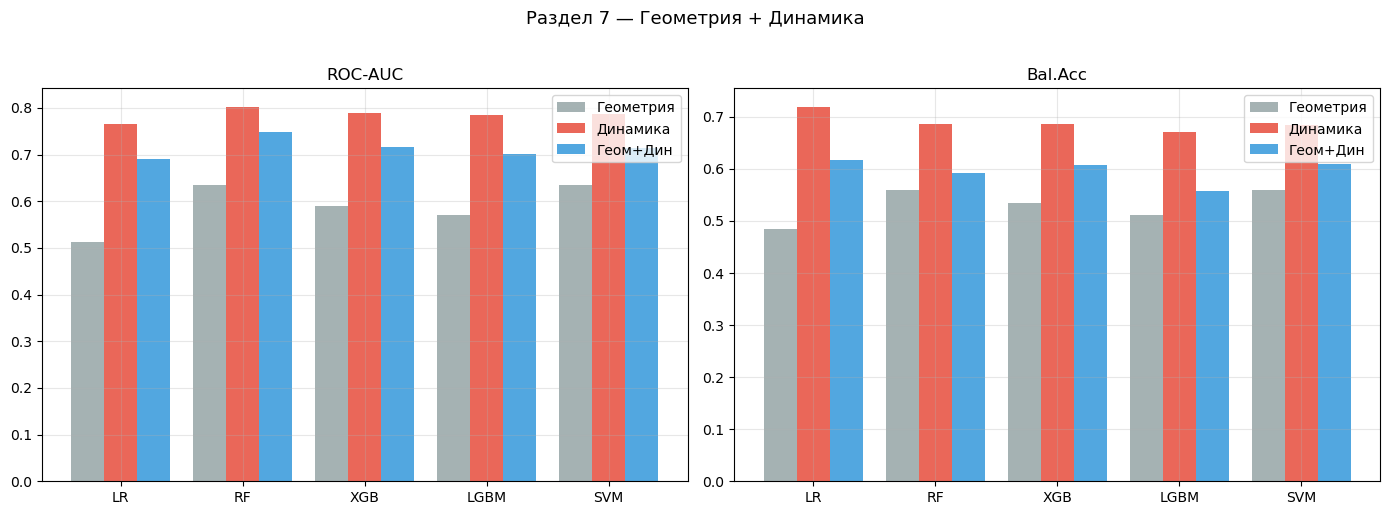

In [32]:
rows = []
for mn in model_names:
    r = res_geo_dyn[mn]; r0 = res_no[mn]; rd = res_dyn[mn]
    rows.append({'Model': mn,
        'Геом':       f'{r0["roc_auc"][0]:.3f}',
        'Динамика':   f'{rd["roc_auc"][0]:.3f}',
        'Геом+Дин':   f'{r["roc_auc"][0]:.3f}±{r["roc_auc"][1]:.3f}',
        'ΔAUC':       f'{r["roc_auc"][0]-r0["roc_auc"][0]:+.3f}',
        'Bal.Acc':    f'{r["balanced_accuracy"][0]:.3f}',
        'Sens':       f'{r["sensitivity"][0]:.3f}',
        'Spec':       f'{r["specificity"][0]:.3f}',
    })
display(pd.DataFrame(rows))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Раздел 7 — Геометрия + Динамика', fontsize=13, y=1.02)
x = np.arange(len(model_names)); w = 0.27
for ax_i, (metric, label) in enumerate([('roc_auc','ROC-AUC'),('balanced_accuracy','Bal.Acc')]):
    v0 = [res_no[m][metric][0] for m in model_names]
    vd = [res_dyn[m][metric][0] for m in model_names]
    vgd = [res_geo_dyn[m][metric][0] for m in model_names]
    axes[ax_i].bar(x-w, v0, w, label='Геометрия', color='#95a5a6', alpha=0.85)
    axes[ax_i].bar(x,   vd, w, label='Динамика',  color='#e74c3c', alpha=0.85)
    axes[ax_i].bar(x+w, vgd, w, label='Геом+Дин', color='#3498db', alpha=0.85)
    axes[ax_i].set_xticks(x); axes[ax_i].set_xticklabels(model_names)
    axes[ax_i].set_title(label); axes[ax_i].legend(); axes[ax_i].grid(alpha=0.3)
plt.tight_layout(); plt.show()

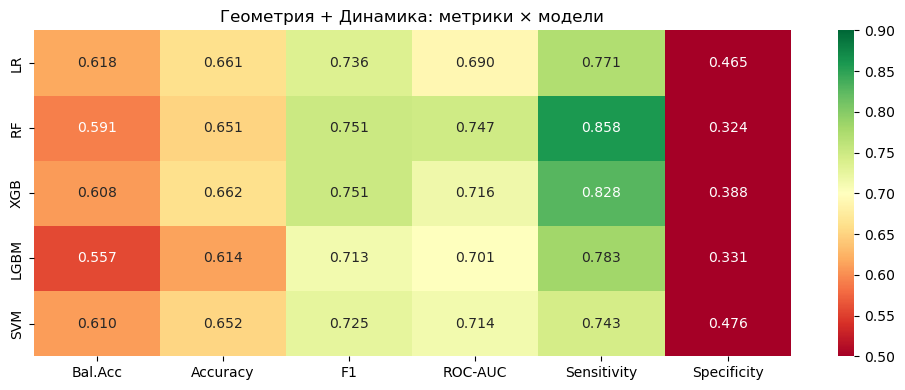

In [33]:
hm7 = np.zeros((len(model_names), len(metrics_list)))
for i, mn in enumerate(model_names):
    for j, met in enumerate(metrics_list): hm7[i,j] = res_geo_dyn[mn][met][0]
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(hm7, xticklabels=metric_labels, yticklabels=model_names,
            annot=True, fmt='.3f', cmap='RdYlGn', vmin=0.5, vmax=0.9, ax=ax)
ax.set_title('Геометрия + Динамика: метрики × модели')
plt.tight_layout(); plt.show()

## 8. + Угловые признаки

`mean_angle` — средний угол вектора i→j (направление пары).  
`std_angle` — разброс угла во времени (нестабильность направления).  
`range_angle` — диапазон отклонения (асимметрия нахмуривания).

In [35]:
feat_geo_dyn_ang = feat_geo_dyn + feat_ang
print(f'Геом+Дин ({len(feat_geo_dyn)}) + Углы ({len(feat_ang)}) = {len(feat_geo_dyn_ang)} признаков')
print('Обучаю...')
res_geo_dyn_ang = run_all(df[feat_geo_dyn_ang], y, groups)
print('Готово.')

Геом+Дин (250) + Углы (75) = 325 признаков
Обучаю...
Готово.


,Model,Геом+Дин,Геом+Дин+Углы,ΔAUC,Bal.Acc,Sens,Spec
0,LR,0.690,0.723±0.115,+0.033,0.641,0.765,0.516
1,RF,0.747,0.771±0.078,+0.024,0.623,0.872,0.374
2,XGB,0.716,0.787±0.068,+0.071,0.670,0.841,0.499
3,LGBM,0.701,0.788±0.057,+0.087,0.666,0.854,0.479
4,SVM,0.714,0.757±0.075,+0.043,0.639,0.771,0.508


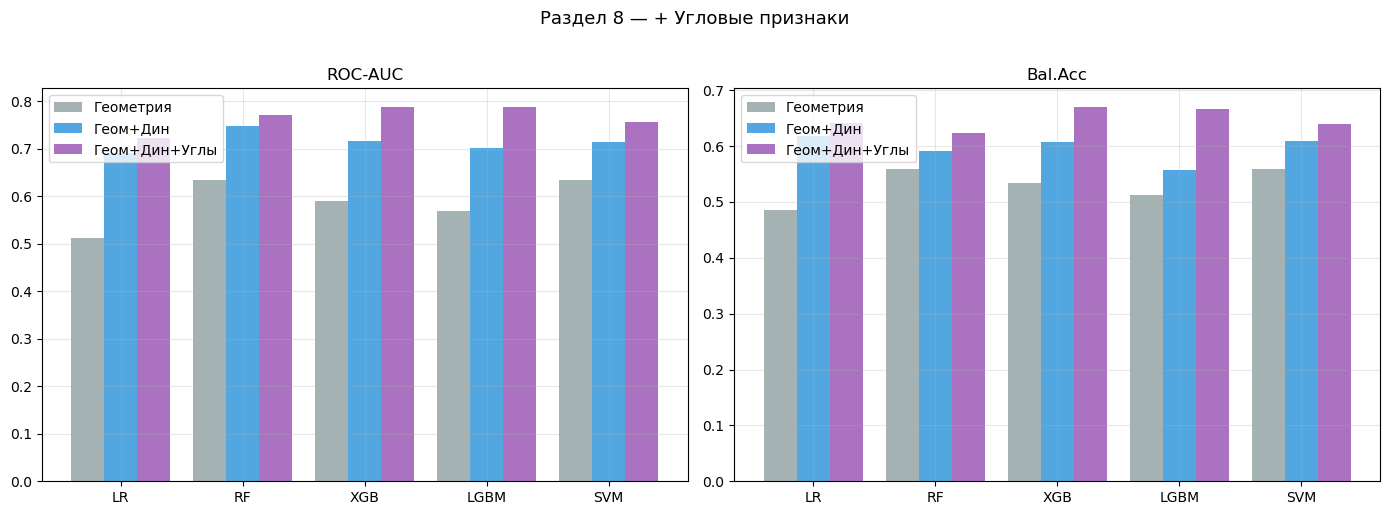

In [36]:
rows = []
for mn in model_names:
    r = res_geo_dyn_ang[mn]; rp = res_geo_dyn[mn]
    rows.append({'Model': mn,
        'Геом+Дин':        f'{rp["roc_auc"][0]:.3f}',
        'Геом+Дин+Углы':   f'{r["roc_auc"][0]:.3f}±{r["roc_auc"][1]:.3f}',
        'ΔAUC':            f'{r["roc_auc"][0]-rp["roc_auc"][0]:+.3f}',
        'Bal.Acc':         f'{r["balanced_accuracy"][0]:.3f}',
        'Sens':            f'{r["sensitivity"][0]:.3f}',
        'Spec':            f'{r["specificity"][0]:.3f}',
    })
display(pd.DataFrame(rows))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Раздел 8 — + Угловые признаки', fontsize=13, y=1.02)
x = np.arange(len(model_names)); w = 0.27
for ax_i, (metric, label) in enumerate([('roc_auc','ROC-AUC'),('balanced_accuracy','Bal.Acc')]):
    v0 = [res_no[m][metric][0] for m in model_names]
    vgd = [res_geo_dyn[m][metric][0] for m in model_names]
    vgda = [res_geo_dyn_ang[m][metric][0] for m in model_names]
    axes[ax_i].bar(x-w, v0, w, label='Геометрия', color='#95a5a6', alpha=0.85)
    axes[ax_i].bar(x, vgd, w, label='Геом+Дин',   color='#3498db', alpha=0.85)
    axes[ax_i].bar(x+w, vgda, w, label='Геом+Дин+Углы', color='#9b59b6', alpha=0.85)
    axes[ax_i].set_xticks(x); axes[ax_i].set_xticklabels(model_names)
    axes[ax_i].set_title(label); axes[ax_i].legend(); axes[ax_i].grid(alpha=0.3)
plt.tight_layout(); plt.show()

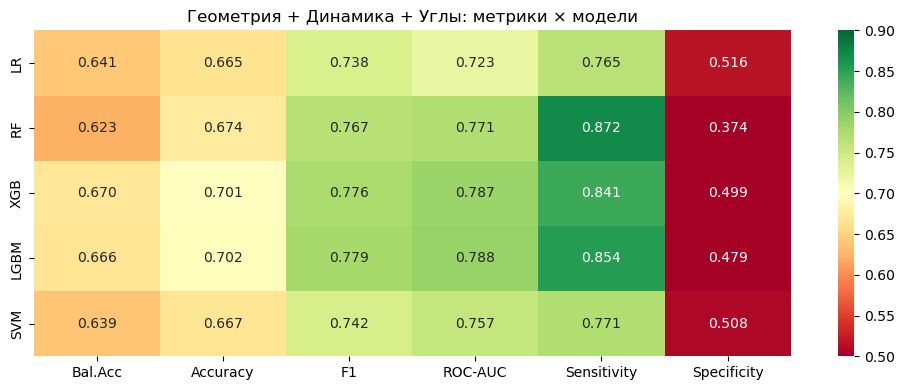

In [37]:
hm8 = np.zeros((len(model_names), len(metrics_list)))
for i, mn in enumerate(model_names):
    for j, met in enumerate(metrics_list): hm8[i,j] = res_geo_dyn_ang[mn][met][0]
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(hm8, xticklabels=metric_labels, yticklabels=model_names,
            annot=True, fmt='.3f', cmap='RdYlGn', vmin=0.5, vmax=0.9, ax=ax)
ax.set_title('Геометрия + Динамика + Углы: метрики × модели')
plt.tight_layout(); plt.show()

## 9. Все доступные dist_ признаки

Все дистанционные колонки: геометрия + динамика + углы (без площадных `area_`).

In [39]:
print(f'Все dist_ признаки: {len(feat_all_dist)}')
print('Обучаю...')
res_all = run_all(df[feat_all_dist], y, groups)
print('Готово.')

Все dist_ признаки: 325
Обучаю...
Готово.


,Model,Геом,Все dist_,ΔAUC,Bal.Acc,Sens,Spec
0,LR,0.512,0.723±0.114,+0.211,0.644,0.772,0.516
1,RF,0.634,0.768±0.083,+0.134,0.607,0.866,0.348
2,XGB,0.590,0.792±0.063,+0.201,0.680,0.854,0.507
3,LGBM,0.570,0.786±0.060,+0.216,0.676,0.841,0.510
4,SVM,0.635,0.757±0.076,+0.122,0.639,0.771,0.508


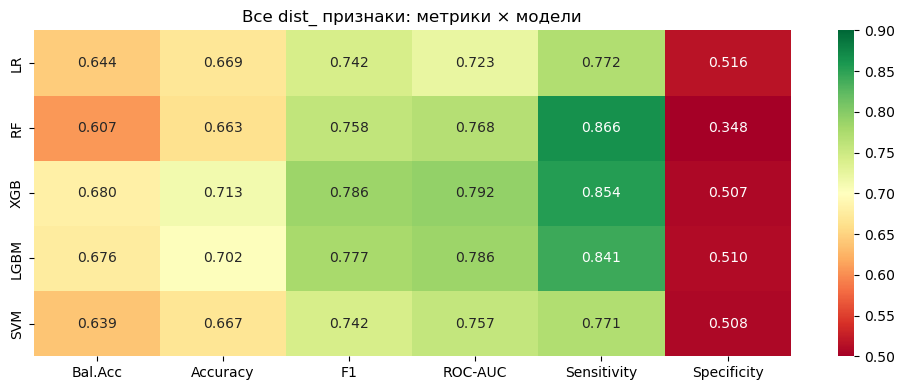

In [40]:
rows = []
for mn in model_names:
    r = res_all[mn]; r0 = res_no[mn]
    rows.append({'Model': mn,
        'Геом':      f'{r0["roc_auc"][0]:.3f}',
        'Все dist_': f'{r["roc_auc"][0]:.3f}±{r["roc_auc"][1]:.3f}',
        'ΔAUC':      f'{r["roc_auc"][0]-r0["roc_auc"][0]:+.3f}',
        'Bal.Acc':   f'{r["balanced_accuracy"][0]:.3f}',
        'Sens':      f'{r["sensitivity"][0]:.3f}',
        'Spec':      f'{r["specificity"][0]:.3f}',
    })
display(pd.DataFrame(rows))

hm9 = np.zeros((len(model_names), len(metrics_list)))
for i, mn in enumerate(model_names):
    for j, met in enumerate(metrics_list): hm9[i,j] = res_all[mn][met][0]
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(hm9, xticklabels=metric_labels, yticklabels=model_names,
            annot=True, fmt='.3f', cmap='RdYlGn', vmin=0.5, vmax=0.9, ax=ax)
ax.set_title('Все dist_ признаки: метрики × модели')
plt.tight_layout(); plt.show()

## 10. Площадные признаки (треугольники)

**Мотивация:** треугольные площади (`area_X_Y_Z`) отражают деформацию лицевых регионов —  
насколько изменяется форма треугольника между тремя landmark-точками во время нахмуривания.  
309 треугольников × 6 агрегатов (`min/max/mean/median/std/range`) = 408 признаков.

Сравниваются три конфигурации: только площади / только dist_ / площади + dist_.

### Схема треугольников на лице

Визуализация 309 треугольников, образованных комбинациями landmark-точек из 4 групп нахмуривания.  
Каждый цвет — отдельная группа. Точки нормированы по эталонному MediaPipe face mesh.

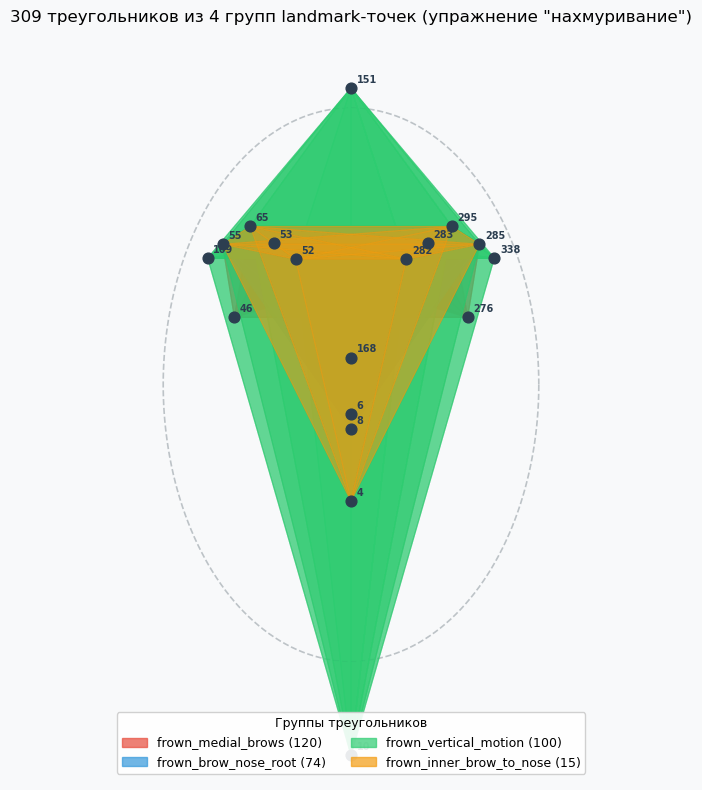

Всего треугольников: 359


In [43]:
# Аппроксимированные 2D-координаты MediaPipe landmarks (нормировано 0–1, y: 0=верх)
COORDS = {
    55: (0.37, 0.358),
    53: (0.422, 0.357),
    52: (0.444, 0.373),
    65: (0.398, 0.34),
    46: (0.382, 0.432),
    109: (0.355, 0.372),
    285: (0.63, 0.358),
    283: (0.578, 0.357),
    282: (0.556, 0.373),
    295: (0.602, 0.34),
    276: (0.618, 0.432),
    338: (0.645, 0.372),
    168: (0.5, 0.473),
    6: (0.5, 0.53),
    8: (0.5, 0.545),
    4: (0.5, 0.618),
    151: (0.5, 0.2),
    10: (0.5, 0.875),
}

GROUPS = {
    'frown_medial_brows (120)': ([46, 52, 53, 55, 65, 276, 282, 283, 285, 295], '#e74c3c'),
    'frown_brow_nose_root (74)': ([6, 8, 52, 55, 65, 168, 282, 285, 295], '#3498db'),
    'frown_vertical_motion (100)': ([10, 52, 55, 65, 109, 151, 282, 285, 295, 338], '#2ecc71'),
    'frown_inner_brow_to_nose (15)': ([4, 52, 55, 65, 282, 285, 295], '#f39c12'),
}

from itertools import combinations
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(10, 8))
ax.set_facecolor('#f8f9fa'); fig.patch.set_facecolor('#f8f9fa')

for group_name, (indices, color) in GROUPS.items():
    valid = [lm for lm in indices if lm in COORDS]
    for (i, j, k) in combinations(valid, 3):
        xi, yi = COORDS[i]; xj, yj = COORDS[j]; xk, yk = COORDS[k]
        tri = plt.Polygon([(xi,1-yi),(xj,1-yj),(xk,1-yk)],
                          facecolor=color, alpha=0.15, edgecolor=color, linewidth=0.8)
        ax.add_patch(tri)

for lm, (lx, ly) in COORDS.items():
    ax.scatter(lx, 1-ly, s=60, c='#2c3e50', zorder=5)
    ax.annotate(str(lm), (lx, 1-ly), textcoords='offset points',
                xytext=(4, 4), fontsize=13, color='#2c3e50', fontweight='bold')

patches = [mpatches.Patch(color=color, alpha=0.7, label=name)
           for name, (_, color) in GROUPS.items()]
ax.legend(handles=patches, loc='lower center', ncol=2, fontsize=13,
          framealpha=0.9, title='Группы треугольников', title_fontsize=13)

theta = np.linspace(0, 2*np.pi, 200)
ax.plot(0.5+0.19*np.cos(theta), 0.5+0.28*np.sin(theta), '--', color='#bdc3c7', lw=1.2, zorder=0)

ax.set_xlim(0.28, 0.72); ax.set_ylim(0.10, 0.85)
ax.set_aspect('equal')
ax.set_title('309 треугольников из 4 групп landmark-точек (упражнение "нахмуривание")',
             fontsize=13, pad=12)
ax.axis('off')
plt.tight_layout(); plt.show()
print(f'Всего треугольников: {sum(len(list(combinations([lm for lm in g[0] if lm in COORDS],3))) for g in GROUPS.values())}')


In [44]:
print(f'Площадные признаки: {len(feat_area)}')
print('Обучаю на площадях...')
res_area = run_all(df[feat_area], y, groups)
print('Готово.')

Площадные признаки: 1854
Обучаю на площадях...
Готово.


,Model,ROC-AUC (area),ROC-AUC (геом),ΔAUC,Bal.Acc,Sens,Spec
0,LR,0.647±0.120,0.512,+0.134,0.567,0.728,0.406
1,RF,0.671±0.070,0.634,+0.037,0.577,0.834,0.321
2,XGB,0.627±0.139,0.590,+0.037,0.581,0.782,0.379
3,LGBM,0.641±0.139,0.570,+0.072,0.566,0.751,0.381
4,SVM,0.683±0.111,0.635,+0.048,0.619,0.711,0.527


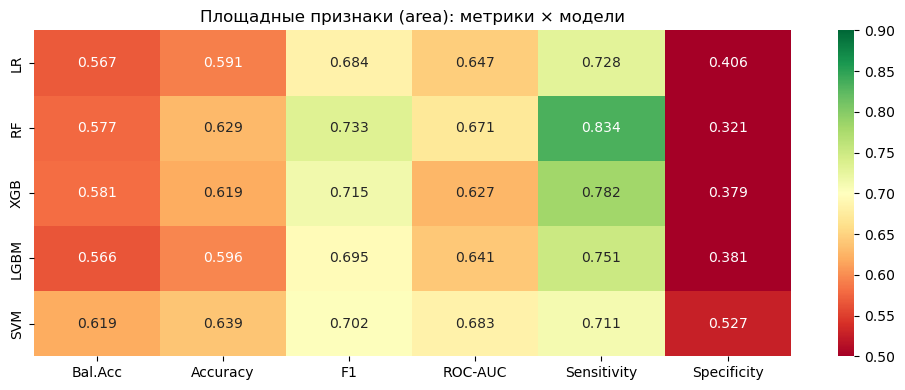

In [45]:
rows = []
for mn in model_names:
    r = res_area[mn]; r0 = res_no[mn]
    rows.append({'Model': mn,
        'ROC-AUC (area)': f'{r["roc_auc"][0]:.3f}±{r["roc_auc"][1]:.3f}',
        'ROC-AUC (геом)': f'{r0["roc_auc"][0]:.3f}',
        'ΔAUC':           f'{r["roc_auc"][0]-r0["roc_auc"][0]:+.3f}',
        'Bal.Acc':        f'{r["balanced_accuracy"][0]:.3f}',
        'Sens':           f'{r["sensitivity"][0]:.3f}',
        'Spec':           f'{r["specificity"][0]:.3f}',
    })
display(pd.DataFrame(rows))

hm10a = np.array([[res_area[mn][met][0] for met in metrics_list] for mn in model_names])
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(hm10a, xticklabels=metric_labels, yticklabels=model_names,
            annot=True, fmt='.3f', cmap='RdYlGn', vmin=0.5, vmax=0.9, ax=ax)
ax.set_title('Площадные признаки (area): метрики × модели')
plt.tight_layout(); plt.show()

Все dist_ + area: 325 + 1854 = 2179 признаков
Обучаю...
Готово.


,Model,Площади,Все dist_,dist_ + площади,ΔAUC vs dist_,Bal.Acc
0,LR,0.647,0.723,0.762±0.101,+0.039,0.657
1,RF,0.671,0.768,0.754±0.059,-0.014,0.613
2,XGB,0.627,0.792,0.745±0.084,-0.046,0.671
3,LGBM,0.641,0.786,0.754±0.093,-0.032,0.631
4,SVM,0.683,0.757,0.768±0.093,+0.011,0.670


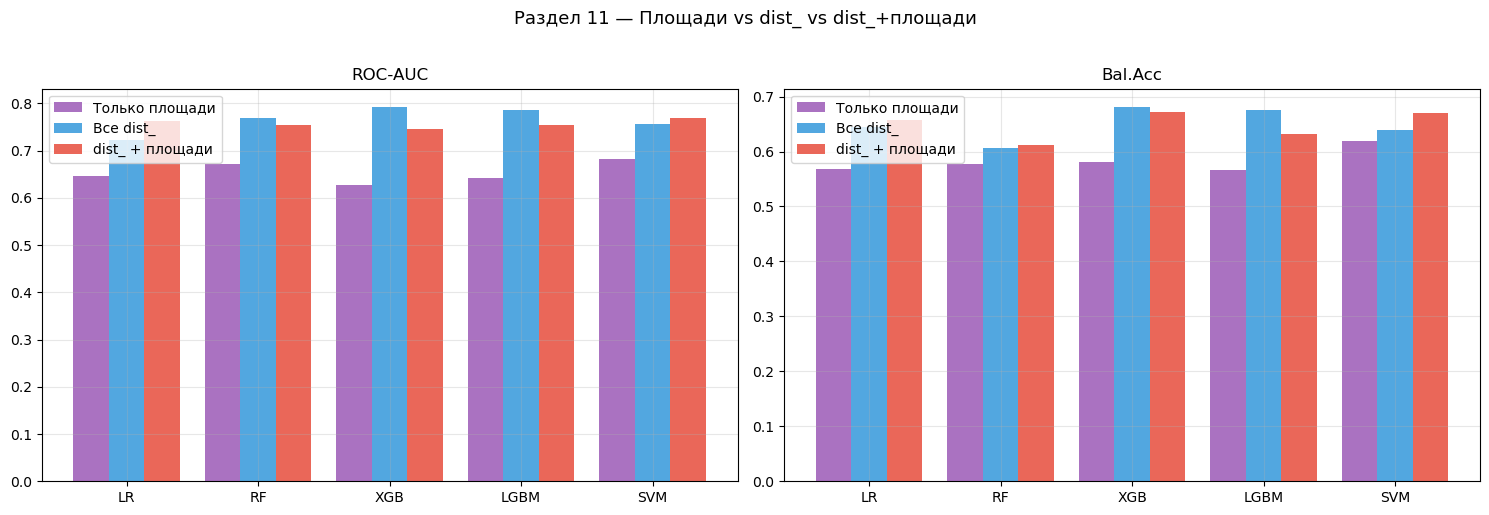

In [46]:
feat_area_all = feat_all_dist + feat_area
print(f'Все dist_ + area: {len(feat_all_dist)} + {len(feat_area)} = {len(feat_area_all)} признаков')
print('Обучаю...')
res_area_all = run_all(df[feat_area_all], y, groups)
print('Готово.')

rows = []
for mn in model_names:
    ra = res_area[mn]; rd = res_all[mn]; rc = res_area_all[mn]
    rows.append({'Model': mn,
        'Площади':         f'{ra["roc_auc"][0]:.3f}',
        'Все dist_':       f'{rd["roc_auc"][0]:.3f}',
        'dist_ + площади': f'{rc["roc_auc"][0]:.3f}±{rc["roc_auc"][1]:.3f}',
        'ΔAUC vs dist_':   f'{rc["roc_auc"][0]-rd["roc_auc"][0]:+.3f}',
        'Bal.Acc':         f'{rc["balanced_accuracy"][0]:.3f}',
    })
display(pd.DataFrame(rows))

x = np.arange(len(model_names)); w = 0.27
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Раздел 11 — Площади vs dist_ vs dist_+площади', fontsize=13, y=1.02)
for ax_i, (metric, label) in enumerate([('roc_auc','ROC-AUC'),('balanced_accuracy','Bal.Acc')]):
    v1 = [res_area[m][metric][0] for m in model_names]
    v2 = [res_all[m][metric][0] for m in model_names]
    v3 = [res_area_all[m][metric][0] for m in model_names]
    axes[ax_i].bar(x-w, v1, w, label='Только площади', color='#9b59b6', alpha=0.85)
    axes[ax_i].bar(x,   v2, w, label='Все dist_',       color='#3498db', alpha=0.85)
    axes[ax_i].bar(x+w, v3, w, label='dist_ + площади', color='#e74c3c', alpha=0.85)
    axes[ax_i].set_xticks(x); axes[ax_i].set_xticklabels(model_names)
    axes[ax_i].set_title(label); axes[ax_i].legend(); axes[ax_i].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 11. Добавление exercise_duration ко всем конфигурациям

`exercise_duration` — длительность выполнения упражнения. Брадикинезия при ПД проявляется  
в увеличении времени выполнения моторного акта → клинически информативный признак.

Каждая конфигурация прогоняется дважды: без и с `exercise_duration`.

In [48]:
dur_col = [DURATION_COL] if DURATION_COL in df.columns else []

configs_for_dur = {
    '5. Геометрия':          feat_geom,
    '6. Динамика':           feat_dyn,
    '7. Геом+Дин':           feat_geo_dyn,
    '8. Геом+Дин+Углы':      feat_geo_dyn_ang,
    '9. Все dist_':          feat_all_dist,
}

res_dur = {}
for label, feats in configs_for_dur.items():
    print(f'  {label} + ex_dur...')
    res_dur[label] = run_all(df[feats + dur_col], y, groups)
print('Готово.')

  5. Геометрия + ex_dur...
  6. Динамика + ex_dur...
  7. Геом+Дин + ex_dur...
  8. Геом+Дин+Углы + ex_dur...
  9. Все dist_ + ex_dur...
Готово.


In [49]:
# Сводная таблица: все конфигурации × без/с ex_duration
def best_auc_row(label, n_feat, res, suffix=''):
    bm  = max(res, key=lambda m: res[m]['roc_auc'][0])
    auc = res[bm]['roc_auc'][0]; std = res[bm]['roc_auc'][1]
    bac = res[bm]['balanced_accuracy'][0]
    sen = res[bm]['sensitivity'][0]; spe = res[bm]['specificity'][0]
    return {'Конфигурация': label + suffix, 'Признаков': n_feat,
            'Лучшая модель': bm,
            'ROC-AUC': f'{auc:.3f}±{std:.3f}',
            'Bal.Acc': f'{bac:.3f}', 'Sens': f'{sen:.3f}', 'Spec': f'{spe:.3f}',
            '_auc': auc}

res_map = {
    '5. Геометрия':     (feat_geom,        res_no),
    '6. Динамика':      (feat_dyn,         res_dyn),
    '7. Геом+Дин':      (feat_geo_dyn,     res_geo_dyn),
    '8. Геом+Дин+Углы': (feat_geo_dyn_ang, res_geo_dyn_ang),
    '9. Все dist_':     (feat_all_dist,    res_all),
}

abl_rows = []
for label, (feats, res) in res_map.items():
    abl_rows.append(best_auc_row(label, len(feats), res))
    abl_rows.append(best_auc_row(label, len(feats)+len(dur_col), res_dur[label], ' + ex_dur'))

abl_df = pd.DataFrame(abl_rows)
display(abl_df.drop(columns=['_auc']))

,Конфигурация,Признаков,Лучшая модель,ROC-AUC,Bal.Acc,Sens,Spec
0,5. Геометрия,125,SVM,0.635±0.058,0.560,0.705,0.414
1,5. Геометрия + ex_dur,126,LGBM,0.785±0.065,0.674,0.814,0.533
2,6. Динамика,125,RF,0.802±0.099,0.686,0.866,0.506
3,6. Динамика + ex_dur,126,XGB,0.855±0.083,0.785,0.885,0.684
4,7. Геом+Дин,250,RF,0.747±0.098,0.591,0.858,0.324
5,7. Геом+Дин + ex_dur,251,XGB,0.817±0.077,0.753,0.885,0.622
6,8. Геом+Дин+Углы,325,LGBM,0.788±0.057,0.666,0.854,0.479
7,8. Геом+Дин+Углы + ex_dur,326,XGB,0.860±0.057,0.784,0.879,0.690
8,9. Все dist_,325,XGB,0.792±0.063,0.680,0.854,0.507
9,9. Все dist_ + ex_dur,326,XGB,0.856±0.053,0.761,0.859,0.663


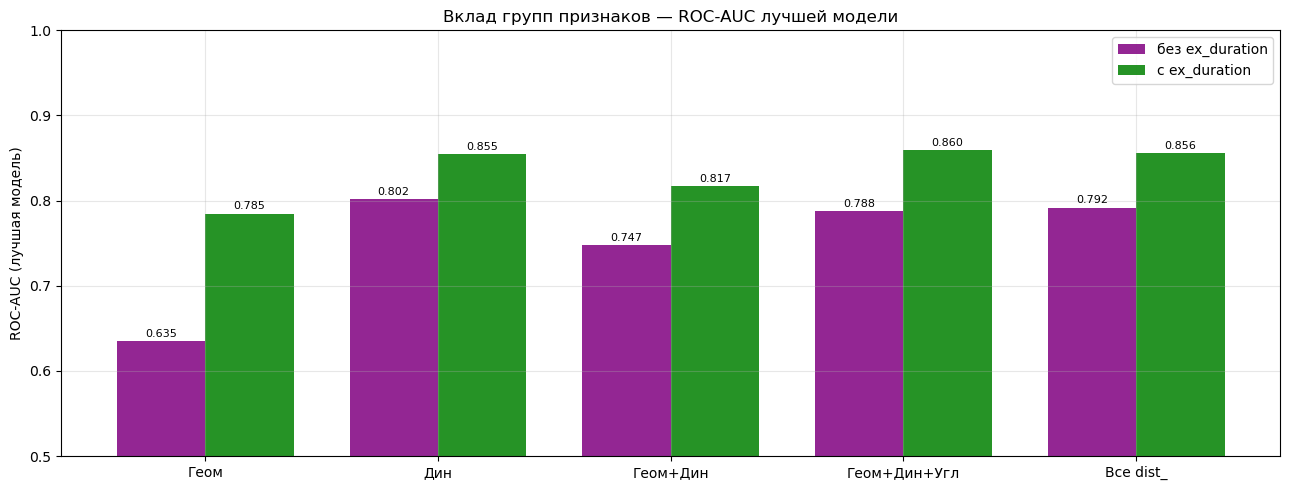

In [50]:
# Bar chart вклада конфигураций (без ex_dur)
labels_short = ['Геом', 'Дин', 'Геом+Дин', 'Геом+Дин+Угл', 'Все dist_']
auc_vals = [res_map[k][1][max(res_map[k][1], key=lambda m: res_map[k][1][m]['roc_auc'][0])]['roc_auc'][0]
            for k in res_map]
auc_dur_vals = [res_dur[k][max(res_dur[k], key=lambda m: res_dur[k][m]['roc_auc'][0])]['roc_auc'][0]
                for k in configs_for_dur]

x = np.arange(len(labels_short)); w = 0.38
fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x-w/2, auc_vals, w, label='без ex_duration', color='purple', alpha=0.85)
ax.bar(x+w/2, auc_dur_vals, w, label='с ex_duration', color='green', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(labels_short)
ax.set_ylabel('ROC-AUC (лучшая модель)'); ax.set_ylim(0.5, 1.0)
ax.set_title('Вклад групп признаков — ROC-AUC лучшей модели'); ax.legend(); ax.grid(alpha=0.3)
for i, v in enumerate(auc_vals):    ax.text(i-w/2, v+0.005, f'{v:.3f}', ha='center', fontsize=13)
for i, v in enumerate(auc_dur_vals): ax.text(i+w/2, v+0.005, f'{v:.3f}', ha='center', fontsize=13)
plt.tight_layout(); plt.show()

## 12. ROC-кривые лучшей конфигурации из Блока 2

Все пять моделей прогоняются на конфигурации, показавшей наибольший ROC-AUC.

Лучшая конфигурация Блока 2: 8. Геом+Дин+Углы+exDur
  Признаков: 326
  Лучшая модель: XGB
  ROC-AUC: 0.860


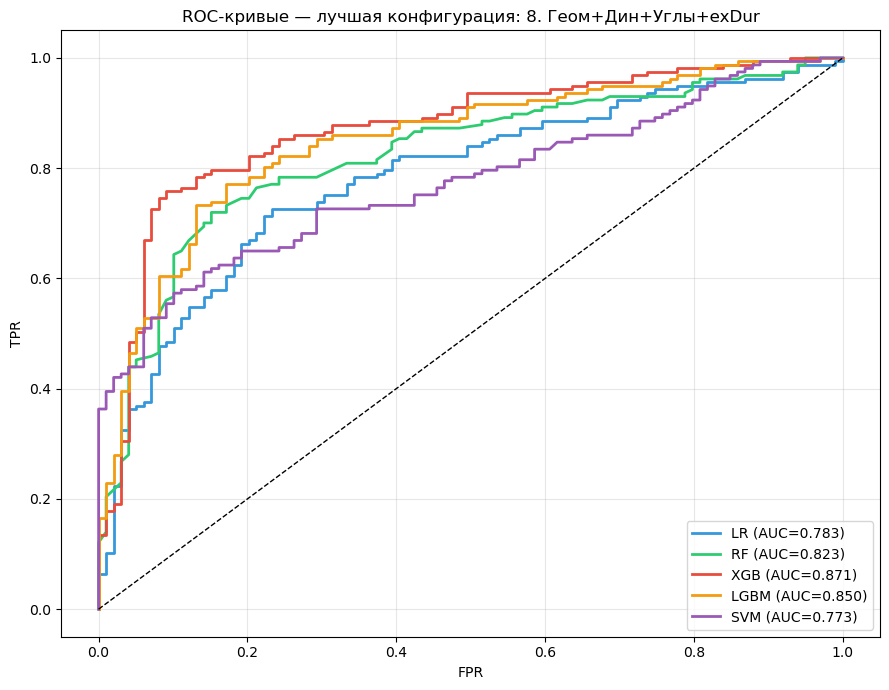

In [52]:
# Определяем лучшую конфигурацию по ablation
_all_res = {
    'Геометрия':     (feat_geom,        res_no),
    'Динамика':      (feat_dyn,         res_dyn),
    'Геом+Дин':      (feat_geo_dyn,     res_geo_dyn),
    'Геом+Дин+Углы': (feat_geo_dyn_ang, res_geo_dyn_ang),
    'Все dist_':     (feat_all_dist,    res_all),
}
for lbl, feats in configs_for_dur.items():
    _all_res[lbl + '+exDur'] = (feats + dur_col, res_dur[lbl])

_best_lbl = max(_all_res, key=lambda k: max(_all_res[k][1][m]['roc_auc'][0] for m in model_names))
_best_feats_bl2, _best_res_bl2 = _all_res[_best_lbl]
_best_model_bl2 = max(_best_res_bl2, key=lambda m: _best_res_bl2[m]['roc_auc'][0])
print(f'Лучшая конфигурация Блока 2: {_best_lbl}')
print(f'  Признаков: {len(_best_feats_bl2)}')
print(f'  Лучшая модель: {_best_model_bl2}')
print(f'  ROC-AUC: {_best_res_bl2[_best_model_bl2]["roc_auc"][0]:.3f}')

X_bl2_best = df[_best_feats_bl2]

fig, ax = plt.subplots(figsize=(9, 7))
cv_roc = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
for name in model_names:
    model = build_models(y)[name]
    oof_pr = np.zeros(len(y))
    for tr, te in cv_roc.split(X_bl2_best, y, groups):
        pipe = Pipeline([('corr', CorrelationFilter()), ('scaler', StandardScaler()), ('model', clone(model))])
        pipe.fit(X_bl2_best.iloc[tr], y.iloc[tr])
        oof_pr[te] = pipe.predict_proba(X_bl2_best.iloc[te])[:,1]
    fpr, tpr, _ = roc_curve(y, oof_pr)
    auc_v = roc_auc_score(y, oof_pr)
    ax.plot(fpr, tpr, color=colors_m[name], lw=2, label=f'{name} (AUC={auc_v:.3f})')
ax.plot([0,1],[0,1],'k--',lw=1)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title(f'ROC-кривые — лучшая конфигурация: {_best_lbl}')
ax.legend(loc='lower right'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

---
## ══ БЛОК 3 — Оптимизация лучшей конфигурации ══

Детальный анализ применяется к **лучшей конфигурации** из Блока 2.  
Пайплайн сохраняется: `CorrelationFilter → StandardScaler → Model`.

In [54]:
# Лучшая конфигурация из Блока 2
_configs_bl3 = {
    'Геометрия':          (feat_geom,        res_no),
    'Динамика':           (feat_dyn,         res_dyn),
    'Геом+Дин':           (feat_geo_dyn,     res_geo_dyn),
    'Геом+Дин+Углы':      (feat_geo_dyn_ang, res_geo_dyn_ang),
    'Все dist_':          (feat_all_dist,    res_all),
}
for lbl, feats in configs_for_dur.items():
    _configs_bl3[lbl + ' + ex_dur'] = (feats + dur_col, res_dur[lbl])

best_feat_label = max(_configs_bl3,
                      key=lambda k: max(_configs_bl3[k][1][m]['roc_auc'][0] for m in model_names))
best_feat, best_res = _configs_bl3[best_feat_label]
X_best = df[best_feat]

best_name = max(best_res, key=lambda m: best_res[m]['roc_auc'][0])
print(f'Лучшая конфигурация: {best_feat_label}')
print(f'  Признаков: {len(best_feat)}')
print(f'  Лучшая модель: {best_name}')
print(f'  ROC-AUC: {best_res[best_name]["roc_auc"][0]:.3f} ± {best_res[best_name]["roc_auc"][1]:.3f}')
print(f'  Bal.Acc: {best_res[best_name]["balanced_accuracy"][0]:.3f}')

Лучшая конфигурация: 8. Геом+Дин+Углы + ex_dur
  Признаков: 326
  Лучшая модель: XGB
  ROC-AUC: 0.860 ± 0.057
  Bal.Acc: 0.784


## 13. Детальная оценка лучшей модели

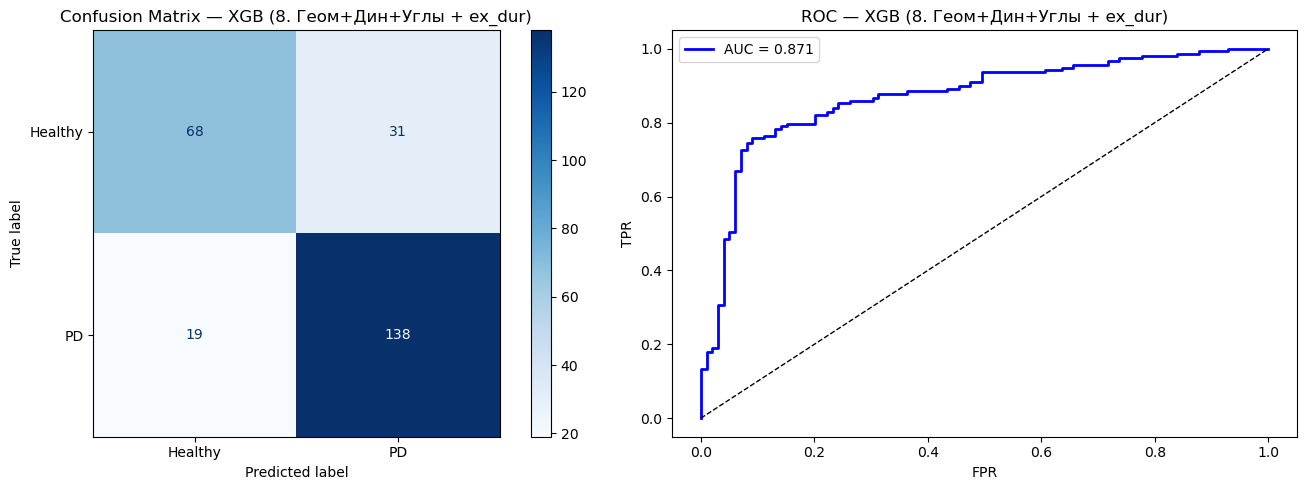

In [56]:
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
best_model_obj = build_models(y)[best_name]

oof_preds = np.zeros(len(y)); oof_proba = np.zeros(len(y))
for tr, te in cv.split(X_best, y, groups):
    pipe = Pipeline([('corr', CorrelationFilter()), ('scaler', StandardScaler()),
                     ('model', clone(best_model_obj))])
    pipe.fit(X_best.iloc[tr], y.iloc[tr])
    oof_preds[te] = pipe.predict(X_best.iloc[te])
    oof_proba[te] = pipe.predict_proba(X_best.iloc[te])[:,1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cm = confusion_matrix(y, oof_preds)
ConfusionMatrixDisplay(cm, display_labels=['Healthy','PD']).plot(
    ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title(f'Confusion Matrix — {best_name} ({best_feat_label})')
fpr, tpr, _ = roc_curve(y, oof_proba)
auc_val = roc_auc_score(y, oof_proba)
axes[1].plot(fpr, tpr, 'b-', lw=2, label=f'AUC = {auc_val:.3f}')
axes[1].plot([0,1],[0,1],'k--',lw=1)
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title(f'ROC — {best_name} ({best_feat_label})'); axes[1].legend()
plt.tight_layout(); plt.show()

## 14. ROC-кривые всех моделей

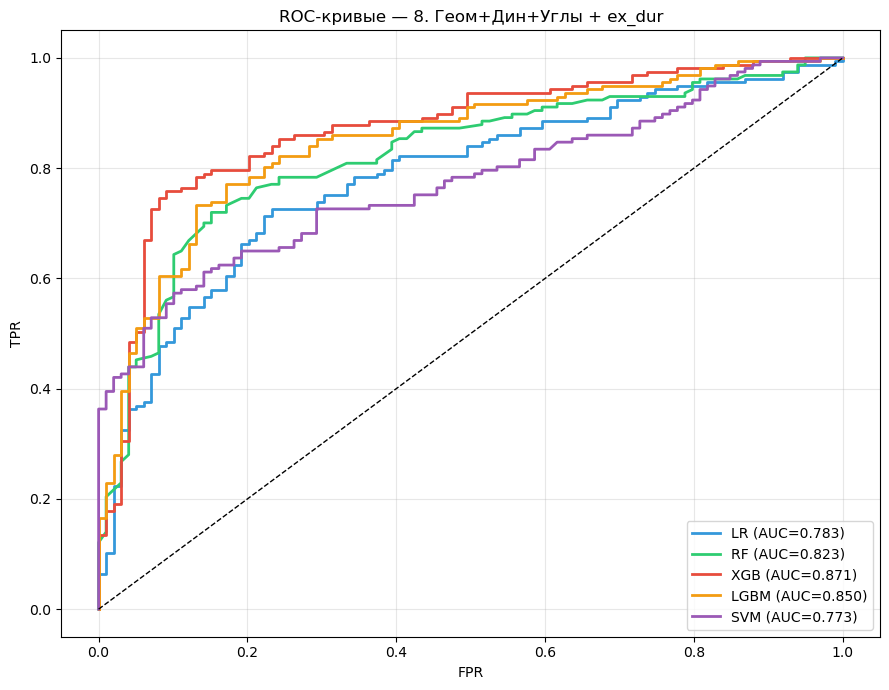

In [58]:
fig, ax = plt.subplots(figsize=(9, 7))
cv_roc = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
for name in model_names:
    model = build_models(y)[name]
    oof_pr = np.zeros(len(y))
    for tr, te in cv_roc.split(X_best, y, groups):
        pipe = Pipeline([('corr', CorrelationFilter()), ('scaler', StandardScaler()),
                         ('model', clone(model))])
        pipe.fit(X_best.iloc[tr], y.iloc[tr])
        oof_pr[te] = pipe.predict_proba(X_best.iloc[te])[:,1]
    fpr, tpr, _ = roc_curve(y, oof_pr)
    auc_v = roc_auc_score(y, oof_pr)
    ax.plot(fpr, tpr, color=colors_m[name], lw=2, label=f'{name} (AUC={auc_v:.3f})')
ax.plot([0,1],[0,1],'k--',lw=1)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title(f'ROC-кривые — {best_feat_label}')
ax.legend(loc='lower right'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 15. Feature importance

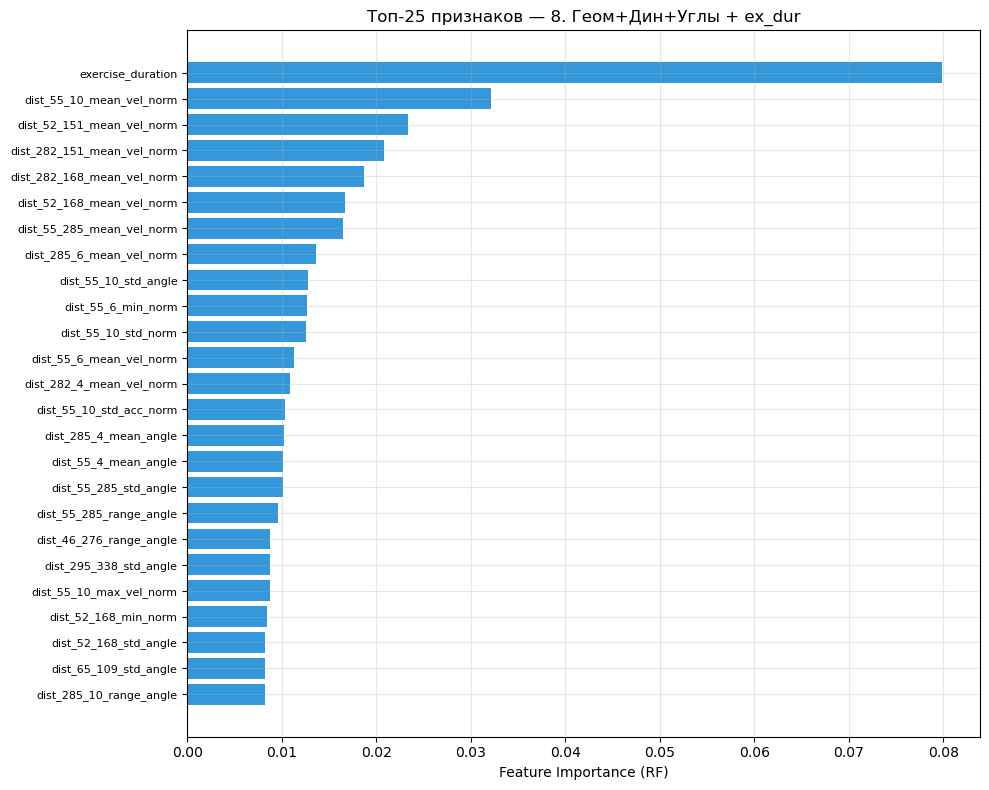

In [60]:
cf_desc = CorrelationFilter(threshold=0.95).fit(X_best)
X_best_f = X_best.iloc[:, np.where(cf_desc.keep_mask_)[0]]
kept_names = X_best_f.columns.tolist()

rf_imp = RandomForestClassifier(n_estimators=500, class_weight='balanced',
                                random_state=RANDOM_STATE, n_jobs=-1)
rf_imp.fit(StandardScaler().fit_transform(X_best_f), y)

imp = pd.DataFrame({'feature': kept_names, 'importance': rf_imp.feature_importances_})
imp = imp.sort_values('importance', ascending=False).head(25)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(range(len(imp)), imp['importance'].values, color='#3498db')
ax.set_yticks(range(len(imp)))
ax.set_yticklabels(imp['feature'].values, fontsize=13)
ax.invert_yaxis()
ax.set_xlabel('Feature Importance (RF)')
ax.set_title(f'Топ-25 признаков — {best_feat_label}')
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### Рейтинг моделей по ROC-AUC

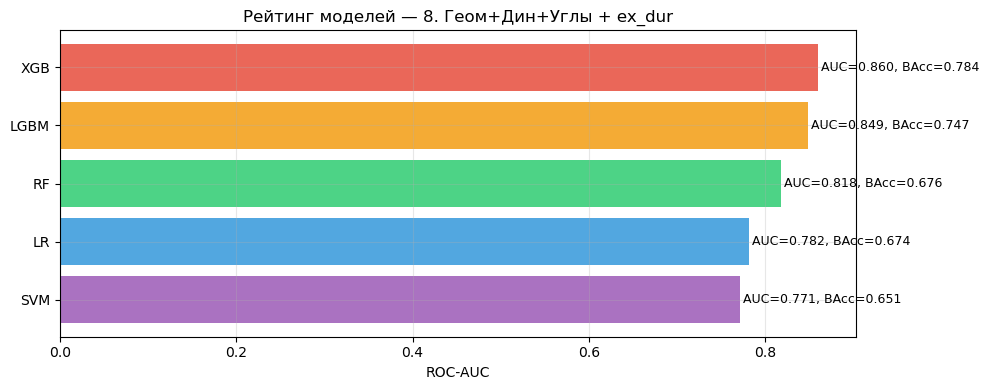

In [62]:
ranking_rows = []
for mn in model_names:
    r = best_res[mn]
    ranking_rows.append({'Model': mn, 'AUC': r['roc_auc'][0], 'BAcc': r['balanced_accuracy'][0]})
rank_df = pd.DataFrame(ranking_rows).sort_values('AUC', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 4))
colors_bar = [colors_m[m] for m in rank_df['Model']]
ax.barh(range(len(rank_df)), rank_df['AUC'].values, color=colors_bar, alpha=0.85)
ax.set_yticks(range(len(rank_df)))
ax.set_yticklabels(rank_df['Model'].values, fontsize=13)
for i, (auc, bacc) in enumerate(zip(rank_df['AUC'], rank_df['BAcc'])):
    ax.text(auc + 0.003, i, f'AUC={auc:.3f}, BAcc={bacc:.3f}', va='center', fontsize=13)
ax.set_xlabel('ROC-AUC')
ax.set_title(f'Рейтинг моделей — {best_feat_label}')
ax.grid(alpha=0.3); ax.invert_yaxis()
plt.tight_layout(); plt.show()

## 16. UMAP — визуализация и препроцессинг

UMAP (Uniform Manifold Approximation and Projection) — нелинейный метод снижения размерности.  
Применяется к **лучшей конфигурации** из Блока 2.

### 16.1 Двумерная визуализация

/opt/anaconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


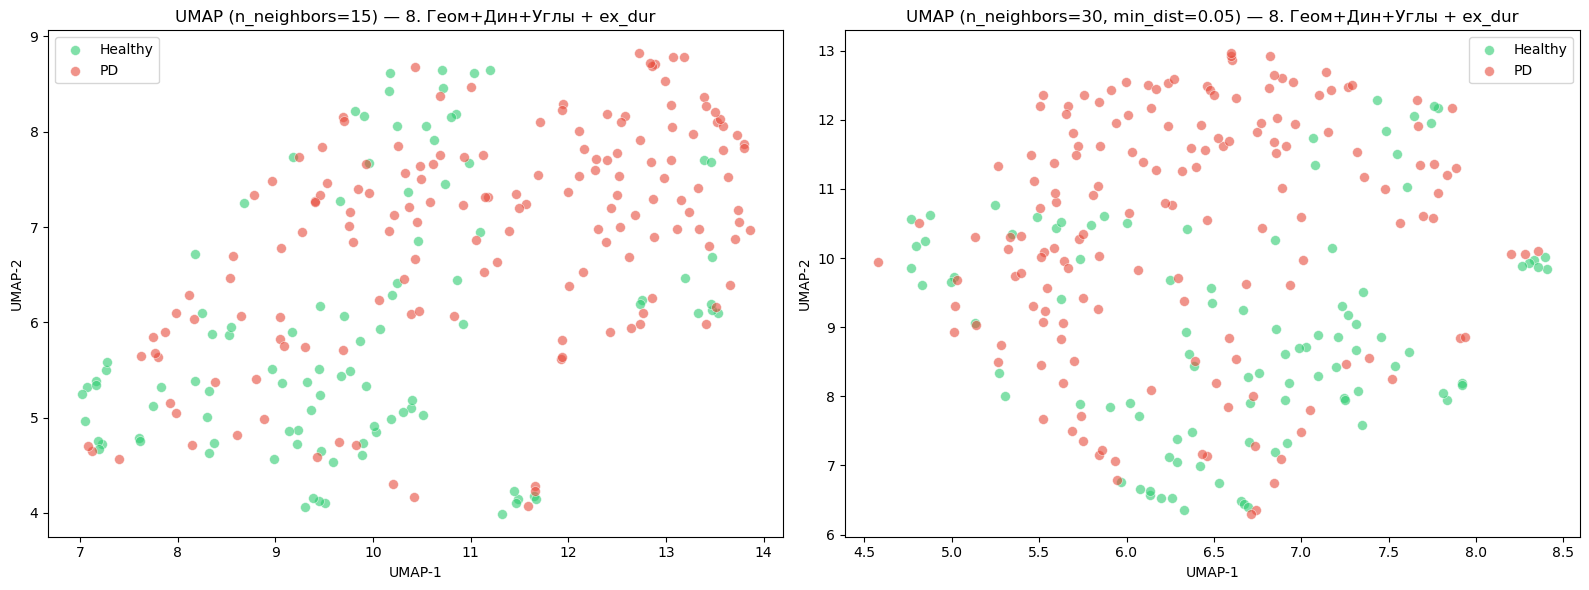

In [65]:
X_best_scaled = StandardScaler().fit_transform(X_best)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
reducer_default = UMAP(n_components=2, random_state=RANDOM_STATE, n_neighbors=15, min_dist=0.1)
X_umap_def = reducer_default.fit_transform(X_best_scaled)
for label, name, color in [(0,'Healthy','#2ecc71'),(1,'PD','#e74c3c')]:
    mask = y == label
    axes[0].scatter(X_umap_def[mask,0], X_umap_def[mask,1], c=color, label=name,
                    alpha=0.6, s=50, edgecolors='white', linewidth=0.5)
axes[0].set_xlabel('UMAP-1'); axes[0].set_ylabel('UMAP-2')
axes[0].set_title(f'UMAP (n_neighbors=15) — {best_feat_label}'); axes[0].legend()

reducer_tight = UMAP(n_components=2, random_state=RANDOM_STATE, n_neighbors=30, min_dist=0.05)
X_umap_tight = reducer_tight.fit_transform(X_best_scaled)
for label, name, color in [(0,'Healthy','#2ecc71'),(1,'PD','#e74c3c')]:
    mask = y == label
    axes[1].scatter(X_umap_tight[mask,0], X_umap_tight[mask,1], c=color, label=name,
                    alpha=0.6, s=50, edgecolors='white', linewidth=0.5)
axes[1].set_xlabel('UMAP-1'); axes[1].set_ylabel('UMAP-2')
axes[1].set_title(f'UMAP (n_neighbors=30, min_dist=0.05) — {best_feat_label}'); axes[1].legend()
plt.tight_layout(); plt.show()

### 16.2 UMAP как препроцессинг

In [67]:
def run_with_umap(X, y, groups, n_components):
    cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    models = build_models(y)
    res = {}
    for name, model in models.items():
        pipe = Pipeline([
            ('corr',   CorrelationFilter(threshold=0.95)),
            ('scaler', StandardScaler()),
            ('umap',   UMAP(n_components=n_components, random_state=RANDOM_STATE, n_neighbors=15)),
            ('model',  model),
        ])
        cvr = cross_validate(pipe, X, y, groups=groups, cv=cv,
                             scoring=scoring, return_train_score=False)
        res[name] = {k: (np.mean(cvr[f'test_{k}']), np.std(cvr[f'test_{k}'])) for k in scoring}
    return res

baseline = best_res
umap_results = {}
for nc in n_components_list:
    print(f'  >>> UMAP n_components={nc}')
    umap_results[nc] = run_with_umap(X_best, y, groups, nc)
print('Готово.')

  >>> UMAP n_components=2


/opt/anaconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for p

  >>> UMAP n_components=5


/opt/anaconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for p

  >>> UMAP n_components=10


/opt/anaconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for p

  >>> UMAP n_components=20


/opt/anaconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for p

Готово.


In [68]:
rows_auc = []; rows_bac = []
for mn in model_names:
    r_a = {'Model': mn, 'Без UMAP': f'{baseline[mn]["roc_auc"][0]:.3f}'}
    r_b = {'Model': mn, 'Без UMAP': f'{baseline[mn]["balanced_accuracy"][0]:.3f}'}
    for nc in n_components_list:
        r_a[f'UMAP-{nc}'] = f'{umap_results[nc][mn]["roc_auc"][0]:.3f}'
        r_b[f'UMAP-{nc}'] = f'{umap_results[nc][mn]["balanced_accuracy"][0]:.3f}'
    rows_auc.append(r_a); rows_bac.append(r_b)
print('ROC-AUC:')
display(pd.DataFrame(rows_auc).set_index('Model'))
print('\nBalanced Accuracy:')
display(pd.DataFrame(rows_bac).set_index('Model'))

ROC-AUC:


,Без UMAP,UMAP-2,UMAP-5,UMAP-10,UMAP-20
Model,,,,,
LR,0.782,0.691,0.680,0.688,0.697
RF,0.818,0.634,0.629,0.640,0.655
XGB,0.860,0.621,0.662,0.610,0.674
LGBM,0.849,0.595,0.645,0.621,0.634
SVM,0.771,0.694,0.670,0.677,0.682



Balanced Accuracy:


,Без UMAP,UMAP-2,UMAP-5,UMAP-10,UMAP-20
Model,,,,,
LR,0.674,0.632,0.632,0.628,0.632
RF,0.676,0.632,0.632,0.632,0.632
XGB,0.784,0.621,0.662,0.610,0.674
LGBM,0.747,0.589,0.641,0.631,0.615
SVM,0.651,0.626,0.632,0.632,0.632


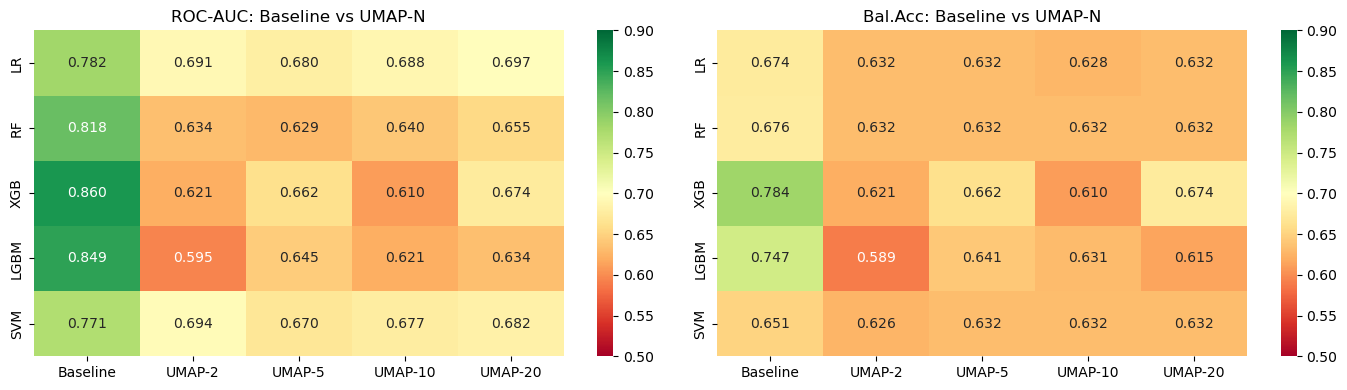

In [69]:
heatmap_auc_u = np.zeros((len(model_names), len(n_components_list)+1))
heatmap_bac_u = np.zeros((len(model_names), len(n_components_list)+1))
col_labels = ['Baseline'] + [f'UMAP-{nc}' for nc in n_components_list]
for i, mn in enumerate(model_names):
    heatmap_auc_u[i,0] = baseline[mn]['roc_auc'][0]
    heatmap_bac_u[i,0] = baseline[mn]['balanced_accuracy'][0]
    for j, nc in enumerate(n_components_list):
        heatmap_auc_u[i,j+1] = umap_results[nc][mn]['roc_auc'][0]
        heatmap_bac_u[i,j+1] = umap_results[nc][mn]['balanced_accuracy'][0]
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.heatmap(heatmap_auc_u, xticklabels=col_labels, yticklabels=model_names,
            annot=True, fmt='.3f', cmap='RdYlGn', vmin=0.5, vmax=0.9, ax=axes[0])
axes[0].set_title('ROC-AUC: Baseline vs UMAP-N')
sns.heatmap(heatmap_bac_u, xticklabels=col_labels, yticklabels=model_names,
            annot=True, fmt='.3f', cmap='RdYlGn', vmin=0.5, vmax=0.9, ax=axes[1])
axes[1].set_title('Bal.Acc: Baseline vs UMAP-N')
plt.tight_layout(); plt.show()

In [70]:
best_umap_auc = 0; best_umap_config = None
for nc in n_components_list:
    for mn in model_names:
        a = umap_results[nc][mn]['roc_auc'][0]
        if a > best_umap_auc:
            best_umap_auc = a; best_umap_config = (nc, mn, umap_results[nc][mn])
nc_b, mn_b, r_b = best_umap_config
bm_base = max(baseline, key=lambda k: baseline[k]['roc_auc'][0])
print(f'Лучшая UMAP-конфигурация: UMAP-{nc_b} + {mn_b}')
print(f'  ROC-AUC: {r_b["roc_auc"][0]:.3f} ± {r_b["roc_auc"][1]:.3f}')
print(f'  Bal.Acc: {r_b["balanced_accuracy"][0]:.3f}')
print(f'\nBaseline ({bm_base}): AUC={baseline[bm_base]["roc_auc"][0]:.3f}')
delta = r_b["roc_auc"][0] - baseline[bm_base]["roc_auc"][0]
print(f'  ΔAUC (UMAP vs baseline): {delta:+.3f}')

Лучшая UMAP-конфигурация: UMAP-20 + LR
  ROC-AUC: 0.697 ± 0.107
  Bal.Acc: 0.632

Baseline (XGB): AUC=0.860
  ΔAUC (UMAP vs baseline): -0.163


## 17. SMOTE — балансировка классов

SMOTE создаёт синтетические наблюдения меньшего класса (Healthy) через интерполяцию.  
Сравнивается с baseline (`class_weight='balanced'`). Применяется к лучшей конфигурации.

In [72]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

def run_with_smote(X, y, groups, k_neighbors=5):
    cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    models = {
        'LR':   LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),
        'RF':   RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
        'XGB':  XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.1,
                              random_state=RANDOM_STATE, eval_metric='logloss'),
        'LGBM': LGBMClassifier(n_estimators=300, max_depth=4, learning_rate=0.1,
                               random_state=RANDOM_STATE, verbose=-1),
        'SVM':  SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE),
    }
    res = {}
    for name, model in models.items():
        pipe = ImbPipeline([
            ('corr',   CorrelationFilter(threshold=0.95)),
            ('scaler', StandardScaler()),
            ('smote',  SMOTE(k_neighbors=k_neighbors, random_state=RANDOM_STATE)),
            ('model',  model),
        ])
        cvr = cross_validate(pipe, X, y, groups=groups, cv=cv,
                             scoring=scoring, return_train_score=False)
        res[name] = {k: (np.mean(cvr[f'test_{k}']), np.std(cvr[f'test_{k}'])) for k in scoring}
    return res

print('SMOTE k=3...'); smote_k3 = run_with_smote(X_best, y, groups, k_neighbors=3)
print('SMOTE k=5...'); smote_k5 = run_with_smote(X_best, y, groups, k_neighbors=5)
print('Готово.')

SMOTE k=3...
SMOTE k=5...
Готово.


In [73]:
rows_auc = []; rows_bac = []
for mn in model_names:
    rows_auc.append({'Model': mn,
        'Baseline (class_weight)': f'{baseline[mn]["roc_auc"][0]:.3f}',
        'SMOTE k=3':               f'{smote_k3[mn]["roc_auc"][0]:.3f}',
        'SMOTE k=5':               f'{smote_k5[mn]["roc_auc"][0]:.3f}'})
    rows_bac.append({'Model': mn,
        'Baseline (class_weight)': f'{baseline[mn]["balanced_accuracy"][0]:.3f}',
        'SMOTE k=3':               f'{smote_k3[mn]["balanced_accuracy"][0]:.3f}',
        'SMOTE k=5':               f'{smote_k5[mn]["balanced_accuracy"][0]:.3f}'})
print('ROC-AUC:')
display(pd.DataFrame(rows_auc).set_index('Model'))
print('\nBalanced Accuracy:')
display(pd.DataFrame(rows_bac).set_index('Model'))

ROC-AUC:


,Baseline (class_weight),SMOTE k=3,SMOTE k=5
Model,,,
LR,0.782,0.768,0.777
RF,0.818,0.803,0.813
XGB,0.860,0.851,0.857
LGBM,0.849,0.849,0.853
SVM,0.771,0.757,0.758



Balanced Accuracy:


,Baseline (class_weight),SMOTE k=3,SMOTE k=5
Model,,,
LR,0.674,0.683,0.670
RF,0.676,0.712,0.727
XGB,0.784,0.773,0.771
LGBM,0.747,0.747,0.765
SVM,0.651,0.622,0.632


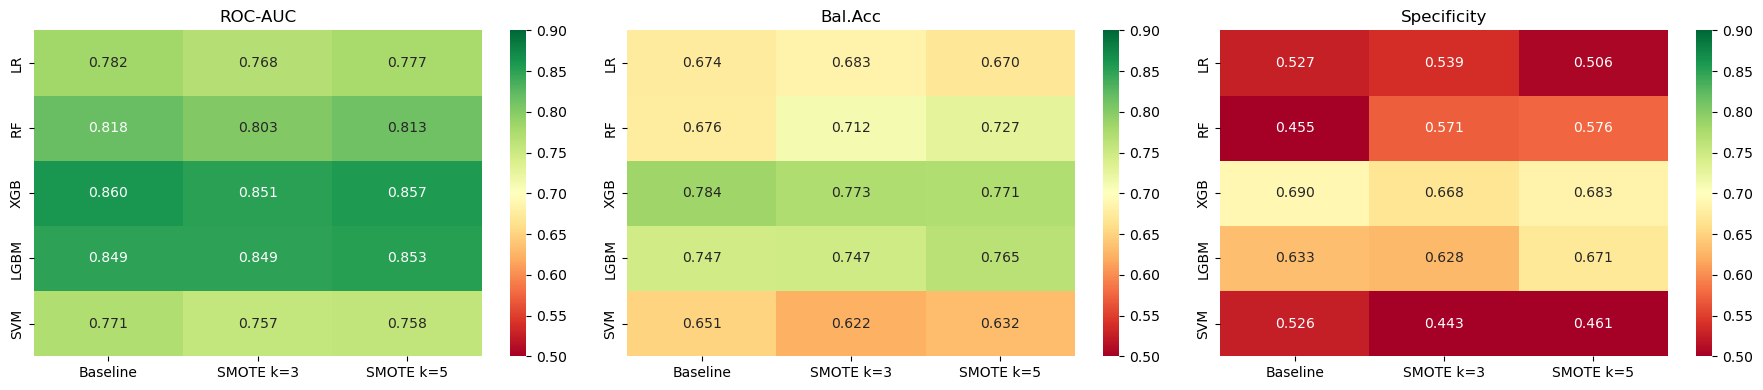

In [74]:
hm_auc = np.zeros((len(model_names), 3))
hm_bac = np.zeros((len(model_names), 3))
hm_spec = np.zeros((len(model_names), 3))
cols_s = ['Baseline', 'SMOTE k=3', 'SMOTE k=5']
for i, mn in enumerate(model_names):
    hm_auc[i,0]=baseline[mn]['roc_auc'][0];           hm_auc[i,1]=smote_k3[mn]['roc_auc'][0];           hm_auc[i,2]=smote_k5[mn]['roc_auc'][0]
    hm_bac[i,0]=baseline[mn]['balanced_accuracy'][0]; hm_bac[i,1]=smote_k3[mn]['balanced_accuracy'][0]; hm_bac[i,2]=smote_k5[mn]['balanced_accuracy'][0]
    hm_spec[i,0]=baseline[mn]['specificity'][0];      hm_spec[i,1]=smote_k3[mn]['specificity'][0];      hm_spec[i,2]=smote_k5[mn]['specificity'][0]
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax_, data, title in zip(axes, [hm_auc, hm_bac, hm_spec], ['ROC-AUC','Bal.Acc','Specificity']):
    sns.heatmap(data, xticklabels=cols_s, yticklabels=model_names,
                annot=True, fmt='.3f', cmap='RdYlGn', vmin=0.5, vmax=0.9, ax=ax_)
    ax_.set_title(title)
plt.tight_layout(); plt.show()

In [75]:
best_smote = None; best_auc_smote = 0
for k, sres in [(3, smote_k3), (5, smote_k5)]:
    for mn in model_names:
        a = sres[mn]['roc_auc'][0]
        if a > best_auc_smote:
            best_auc_smote = a; best_smote = (k, mn, sres[mn])
bm_base = max(baseline, key=lambda m: baseline[m]['roc_auc'][0])
r_base = baseline[bm_base]
k_b, mn_b, r_b = best_smote
print(f'Лучшая SMOTE-конфигурация: SMOTE k={k_b} + {mn_b}')
print(f'  ROC-AUC: {r_b["roc_auc"][0]:.3f} ± {r_b["roc_auc"][1]:.3f}')
print(f'  Spec: {r_b["specificity"][0]:.3f}')
print(f'\nBaseline ({bm_base}): AUC={r_base["roc_auc"][0]:.3f}, Spec={r_base["specificity"][0]:.3f}')
delta = r_b["roc_auc"][0] - r_base["roc_auc"][0]
print(f'  ΔAUC: {delta:+.3f}')

Лучшая SMOTE-конфигурация: SMOTE k=5 + XGB
  ROC-AUC: 0.857 ± 0.063
  Spec: 0.683

Baseline (XGB): AUC=0.860, Spec=0.690
  ΔAUC: -0.003


## 18. Влияние exercise_duration на все конфигурации признаков

`exercise_duration` оценивается как дополнительный признак для каждой группы:  
геометрия, динамика, геом+дин, геом+дин+углы, все dist_.  
Также запускается UMAP и SMOTE с лучшей конфигурацией + ex_duration.

In [77]:
# Для каждой конфигурации: сравниваем AUC без и с exercise_duration
dur_compare_rows = []
for lbl, (feats, res_base) in res_map.items():
    res_wd = res_dur[lbl]
    bm0 = max(res_base, key=lambda m: res_base[m]['roc_auc'][0])
    bm1 = max(res_wd,   key=lambda m: res_wd[m]['roc_auc'][0])
    auc0 = res_base[bm0]['roc_auc'][0]
    auc1 = res_wd[bm1]['roc_auc'][0]
    dur_compare_rows.append({
        'Конфигурация': lbl,
        'AUC без ex_dur': f'{auc0:.3f} ({bm0})',
        'AUC с ex_dur':   f'{auc1:.3f} ({bm1})',
        'ΔAUC':           f'{auc1-auc0:+.3f}',
    })
display(pd.DataFrame(dur_compare_rows))

,Конфигурация,AUC без ex_dur,AUC с ex_dur,ΔAUC
0,5. Геометрия,0.635 (SVM),0.785 (LGBM),+0.150
1,6. Динамика,0.802 (RF),0.855 (XGB),+0.053
2,7. Геом+Дин,0.747 (RF),0.817 (XGB),+0.070
3,8. Геом+Дин+Углы,0.788 (LGBM),0.860 (XGB),+0.072
4,9. Все dist_,0.792 (XGB),0.856 (XGB),+0.064


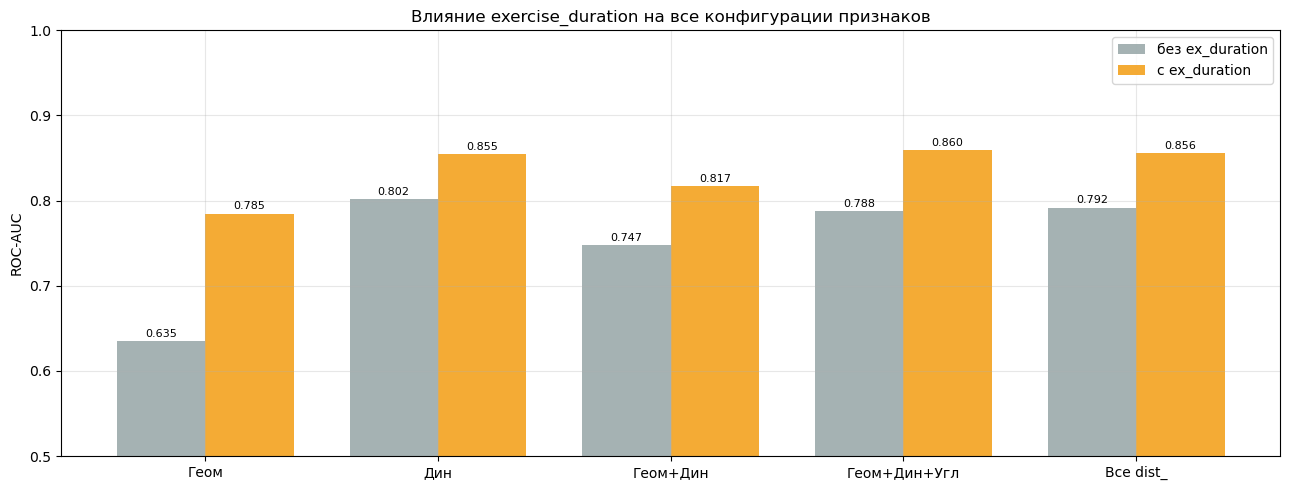

In [78]:
# Визуализация
labels_ex = list(res_map.keys())
auc_no  = [res_map[k][1][max(res_map[k][1], key=lambda m: res_map[k][1][m]['roc_auc'][0])]['roc_auc'][0] for k in labels_ex]
auc_yes = [res_dur[k][max(res_dur[k], key=lambda m: res_dur[k][m]['roc_auc'][0])]['roc_auc'][0] for k in labels_ex]
labels_short2 = ['Геом','Дин','Геом+Дин','Геом+Дин+Угл','Все dist_']

x = np.arange(len(labels_short2)); w = 0.38
fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x-w/2, auc_no, w, label='без ex_duration', color='#95a5a6', alpha=0.85)
ax.bar(x+w/2, auc_yes, w, label='с ex_duration', color='#f39c12', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(labels_short2)
ax.set_ylabel('ROC-AUC'); ax.set_ylim(0.5, 1.0)
ax.set_title('Влияние exercise_duration на все конфигурации признаков')
ax.legend(); ax.grid(alpha=0.3)
for i, (v0, v1) in enumerate(zip(auc_no, auc_yes)):
    ax.text(i-w/2, v0+0.005, f'{v0:.3f}', ha='center', fontsize=13)
    ax.text(i+w/2, v1+0.005, f'{v1:.3f}', ha='center', fontsize=13)
plt.tight_layout(); plt.show()

### 18.1 UMAP и SMOTE с exercise_duration (лучшая конфигурация)

In [80]:
# Лучшая конфигурация с ex_duration
best_ex_lbl = max(configs_for_dur,
    key=lambda k: max(res_dur[k][m]['roc_auc'][0] for m in model_names))
best_ex_feats = configs_for_dur[best_ex_lbl] + dur_col
X_ex_best = df[best_ex_feats]
print(f'Конфигурация для UMAP/SMOTE с ex_dur: {best_ex_lbl} + ex_duration ({len(best_ex_feats)} фич)')

print('UMAP-grid с ex_duration...')
umap_results_ex = {}
for nc in n_components_list:
    print(f'  >>> UMAP n_components={nc}')
    umap_results_ex[nc] = run_with_umap(X_ex_best, y, groups, n_components=nc)
print('\nSMOTE с ex_duration...')
smote_k3_ex = run_with_smote(X_ex_best, y, groups, k_neighbors=3)
smote_k5_ex = run_with_smote(X_ex_best, y, groups, k_neighbors=5)
print('Готово.')

Конфигурация для UMAP/SMOTE с ex_dur: 8. Геом+Дин+Углы + ex_duration (326 фич)
UMAP-grid с ex_duration...
  >>> UMAP n_components=2


/opt/anaconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for p

  >>> UMAP n_components=5


/opt/anaconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for p

  >>> UMAP n_components=10


/opt/anaconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for p

  >>> UMAP n_components=20


/opt/anaconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for p


SMOTE с ex_duration...
Готово.


In [81]:
def best_of(res, metric='roc_auc'):
    bm = max(res, key=lambda m: res[m][metric][0])
    return bm, res[bm][metric][0]

def best_umap_f(umap_res):
    best = (None, None, 0)
    for nc, r in umap_res.items():
        for mn in model_names:
            if r[mn]['roc_auc'][0] > best[2]:
                best = (nc, mn, r[mn]['roc_auc'][0])
    return best

def best_smote_fn(k3, k5):
    best = (None, None, 0)
    for k, r in [(3, k3), (5, k5)]:
        for mn in model_names:
            if r[mn]['roc_auc'][0] > best[2]:
                best = (k, mn, r[mn]['roc_auc'][0])
    return best

bm_ex, a_ex = best_of(res_dur[best_ex_lbl])
nc_ex, mn_ex, a_ex_u = best_umap_f(umap_results_ex)
k_ex, mn_ex_s, a_ex_s = best_smote_fn(smote_k3_ex, smote_k5_ex)

summary_ex_rows = [
    {'Сценарий': f'{best_ex_lbl} + ex_dur (baseline)', 'Модель': bm_ex, 'ROC-AUC': f'{a_ex:.3f}'},
    {'Сценарий': f'UMAP-{nc_ex} + ex_dur',             'Модель': mn_ex, 'ROC-AUC': f'{a_ex_u:.3f}'},
    {'Сценарий': f'SMOTE k={k_ex} + ex_dur',           'Модель': mn_ex_s, 'ROC-AUC': f'{a_ex_s:.3f}'},
]
display(pd.DataFrame(summary_ex_rows))

,Сценарий,Модель,ROC-AUC
0,8. Геом+Дин+Углы + ex_dur (baseline),XGB,0.860
1,UMAP-20 + ex_dur,LR,0.697
2,SMOTE k=5 + ex_dur,XGB,0.857


## 19. Отбор признаков по направлению движения

**Мотивация.** Для каждой пары точек агрегаты `min_norm`/`max_norm` информативны  
только для конкретного направления движения. `DirectionalFeatureSelector` оставляет  
релевантный агрегат по направлению `mean_norm`.

Сравниваются три конфигурации (на геометрическом базисе лучшей конфигурации):
- **Baseline** — все признаки
- **Directional (ε=0.02)** — отбор min/max по направлению
- **Minimal** — только mean/std/median

### 19.1 Разведка направлений

In [84]:
mean_cols_dir = [c for c in best_feat if c.endswith('_mean_norm')]
pair_means_dir = {c.replace('_mean_norm',''): df[c].mean() for c in mean_cols_dir}
pair_df = pd.DataFrame({'pair': list(pair_means_dir.keys()),
                        'mean_norm_avg': list(pair_means_dir.values())})

print(f'Пар точек с mean_norm: {len(pair_df)}')
print(f'Статистика mean_norm_avg:')
print(pair_df['mean_norm_avg'].describe().to_string())
print()
for eps_show in [0.01, 0.02, 0.05, 0.10]:
    expand   = int((pair_df['mean_norm_avg'] > 1 + eps_show).sum())
    contract = int((pair_df['mean_norm_avg'] < 1 - eps_show).sum())
    neutral  = len(pair_df) - expand - contract
    print(f'ε={eps_show:.2f}: expand={expand}, contract={contract}, neutral={neutral}')

Пар точек с mean_norm: 25
Статистика mean_norm_avg:
count    25.000000
mean      1.004559
std       0.024191
min       0.967105
25%       0.986494
50%       1.001693
75%       1.019652
max       1.053390

ε=0.01: expand=12, contract=9, neutral=4
ε=0.02: expand=6, contract=3, neutral=16
ε=0.05: expand=1, contract=0, neutral=24
ε=0.10: expand=0, contract=0, neutral=25


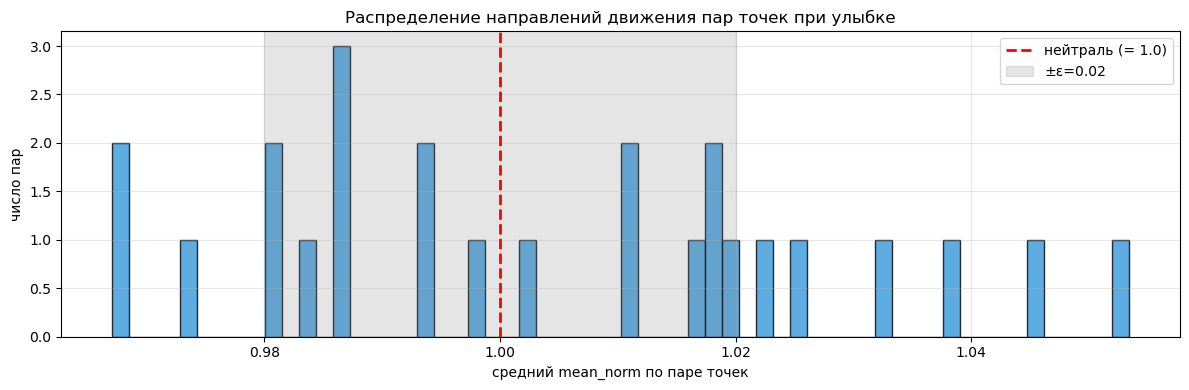

In [85]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.hist(pair_df['mean_norm_avg'], bins=60, color='#3498db', alpha=0.8, edgecolor='black')
ax.axvline(1.0, color='red', ls='--', lw=2, label='нейтраль (= 1.0)')
ax.axvspan(0.98, 1.02, color='gray', alpha=0.2, label='±ε=0.02')
ax.set_xlabel('средний mean_norm по паре точек')
ax.set_ylabel('число пар')
ax.set_title('Распределение направлений движения пар точек при улыбке')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### 19.2 Сравнение Baseline / Directional / Minimal

In [87]:
def run_config(X, y, groups, directional_kwargs):
    cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    models = build_models(y); res = {}
    n_feats_per_fold = None
    for name, model in models.items():
        pipe = Pipeline([
            ('direct', DirectionalFeatureSelector(**directional_kwargs)),
            ('corr',   CorrelationFilter(threshold=0.95)),
            ('scaler', StandardScaler()),
            ('model',  model),
        ])
        cvr = cross_validate(pipe, X, y, groups=groups, cv=cv,
                             scoring=scoring, return_train_score=False,
                             return_estimator=(name == 'LR'))
        if name == 'LR':
            n_feats_per_fold = len(cvr['estimator'][0].named_steps['direct'].keep_columns_)
        res[name] = {k: (np.mean(cvr[f'test_{k}']), np.std(cvr[f'test_{k}'])) for k in scoring}
    res['_n_after_direct'] = n_feats_per_fold
    return res

print('Baseline...'); res_baseline = run_config(X_best, y, groups, {'mode':'none'})
print('Directional ε=0.02...'); res_directional = run_config(X_best, y, groups, {'eps':0.02,'mode':'directional'})
print('Minimal...'); res_minimal = run_config(X_best, y, groups, {'mode':'minimal'})
print('Готово.')
print(f"  Baseline признаков: {res_baseline['_n_after_direct']}")
print(f"  Directional признаков: {res_directional['_n_after_direct']}")
print(f"  Minimal признаков: {res_minimal['_n_after_direct']}")

Baseline...
Directional ε=0.02...
Minimal...
Готово.
  Baseline признаков: 326
  Directional признаков: 287
  Minimal признаков: 276


In [88]:
def summary_table(res, label):
    rows = []
    for mn in model_names:
        r = res[mn]
        rows.append({'Variant': label, 'Model': mn,
            'Bal.Acc': f'{r["balanced_accuracy"][0]:.3f}±{r["balanced_accuracy"][1]:.3f}',
            'F1':      f'{r["f1"][0]:.3f}±{r["f1"][1]:.3f}',
            'ROC-AUC': f'{r["roc_auc"][0]:.3f}±{r["roc_auc"][1]:.3f}',
            'Sens':    f'{r["sensitivity"][0]:.3f}',
            'Spec':    f'{r["specificity"][0]:.3f}',
        })
    return rows

summary_dir = (summary_table(res_baseline, 'Baseline') +
               summary_table(res_directional, 'Directional ε=0.02') +
               summary_table(res_minimal, 'Minimal'))
display(pd.DataFrame(summary_dir))

,Variant,Model,Bal.Acc,F1,ROC-AUC,Sens,Spec
0,Baseline,LR,0.674±0.107,0.774±0.085,0.782±0.133,0.822,0.527
1,Baseline,RF,0.676±0.069,0.800±0.066,0.818±0.082,0.898,0.455
2,Baseline,XGB,0.784±0.045,0.845±0.058,0.860±0.057,0.879,0.690
3,Baseline,LGBM,0.747±0.072,0.818±0.066,0.849±0.030,0.860,0.633
4,Baseline,SVM,0.651±0.098,0.748±0.065,0.771±0.076,0.777,0.526
5,Directional ε=0.02,LR,0.696±0.095,0.792±0.078,0.812±0.118,0.841,0.552
6,Directional ε=0.02,RF,0.700±0.103,0.806±0.082,0.823±0.080,0.891,0.508
7,Directional ε=0.02,XGB,0.765±0.057,0.835±0.063,0.850±0.062,0.879,0.652
8,Directional ε=0.02,LGBM,0.759±0.057,0.828±0.055,0.863±0.039,0.872,0.645
9,Directional ε=0.02,SVM,0.673±0.120,0.758±0.080,0.788±0.084,0.783,0.562


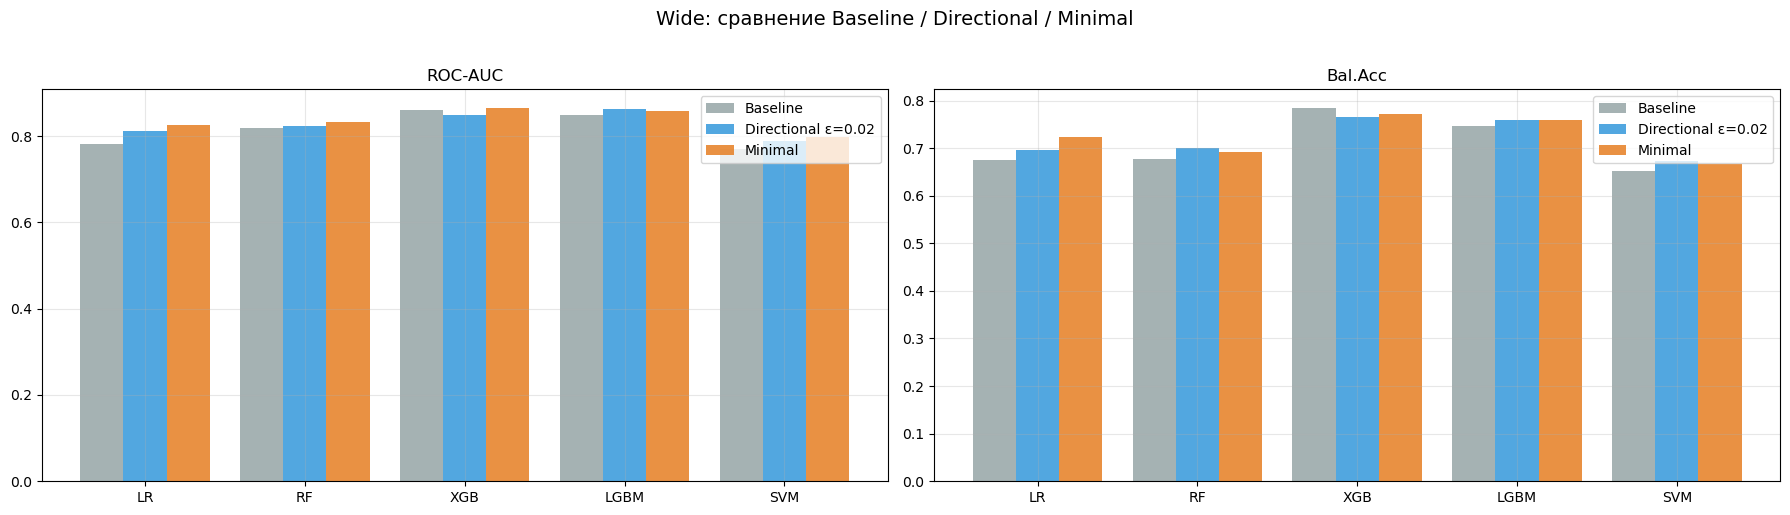

In [89]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
fig.suptitle('Wide: сравнение Baseline / Directional / Minimal', fontsize=14, y=1.02)
x = np.arange(len(model_names)); w = 0.27
for ax_i, (metric, label) in enumerate([('roc_auc','ROC-AUC'),('balanced_accuracy','Bal.Acc')]):
    vb = [res_baseline[m][metric][0] for m in model_names]
    vd = [res_directional[m][metric][0] for m in model_names]
    vm = [res_minimal[m][metric][0] for m in model_names]
    axes[ax_i].bar(x-w, vb, w, label='Baseline',         color='#95a5a6', alpha=0.85)
    axes[ax_i].bar(x,   vd, w, label='Directional ε=0.02', color='#3498db', alpha=0.85)
    axes[ax_i].bar(x+w, vm, w, label='Minimal',          color='#e67e22', alpha=0.85)
    axes[ax_i].set_xticks(x); axes[ax_i].set_xticklabels(model_names)
    axes[ax_i].set_title(label); axes[ax_i].legend(); axes[ax_i].grid(alpha=0.3)
plt.tight_layout(); plt.show()

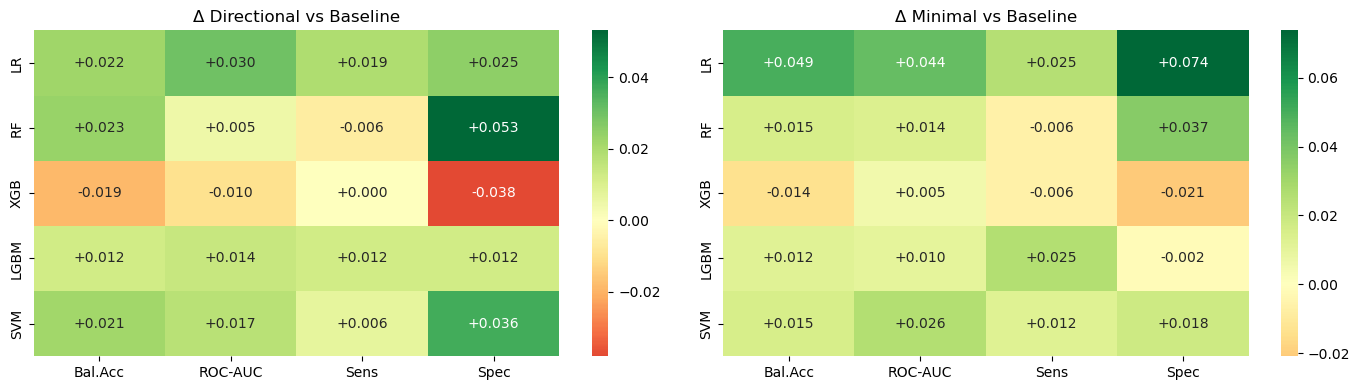

In [90]:
metrics_show = ['balanced_accuracy','roc_auc','sensitivity','specificity']
metric_labels_show = ['Bal.Acc','ROC-AUC','Sens','Spec']
delta_dir = np.zeros((len(model_names), len(metrics_show)))
delta_min = np.zeros((len(model_names), len(metrics_show)))
for i, mn in enumerate(model_names):
    for j, met in enumerate(metrics_show):
        delta_dir[i,j] = res_directional[mn][met][0] - res_baseline[mn][met][0]
        delta_min[i,j] = res_minimal[mn][met][0]     - res_baseline[mn][met][0]
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.heatmap(delta_dir, xticklabels=metric_labels_show, yticklabels=model_names,
            annot=True, fmt='+.3f', cmap='RdYlGn', center=0, ax=axes[0])
axes[0].set_title('Δ Directional vs Baseline')
sns.heatmap(delta_min, xticklabels=metric_labels_show, yticklabels=model_names,
            annot=True, fmt='+.3f', cmap='RdYlGn', center=0, ax=axes[1])
axes[1].set_title('Δ Minimal vs Baseline')
plt.tight_layout(); plt.show()

### 19.3 Sweep по ε

In [92]:
eps_grid = [0.0, 0.01, 0.02, 0.03, 0.05, 0.10]
sweep_results = {}
print('Sweep по ε (LR)...')
for eps_s in eps_grid:
    cv_s = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    pipe = Pipeline([
        ('direct', DirectionalFeatureSelector(eps=eps_s, mode='directional')),
        ('corr',   CorrelationFilter(threshold=0.95)),
        ('scaler', StandardScaler()),
        ('model',  LogisticRegression(max_iter=5000, class_weight='balanced', random_state=RANDOM_STATE)),
    ])
    cvr = cross_validate(pipe, X_best, y, groups=groups, cv=cv_s,
                         scoring=scoring, return_estimator=True)
    n = len(cvr['estimator'][0].named_steps['direct'].keep_columns_)
    sweep_results[eps_s] = {k: (np.mean(cvr[f'test_{k}']), np.std(cvr[f'test_{k}'])) for k in scoring}
    sweep_results[eps_s]['n_after_direct'] = n
    print(f'  ε={eps_s:.2f}: n={n}, AUC={sweep_results[eps_s]["roc_auc"][0]:.3f}')

Sweep по ε (LR)...
  ε=0.00: n=301, AUC=0.798
  ε=0.01: n=297, AUC=0.799
  ε=0.02: n=287, AUC=0.812
  ε=0.03: n=282, AUC=0.821
  ε=0.05: n=277, AUC=0.823
  ε=0.10: n=276, AUC=0.826


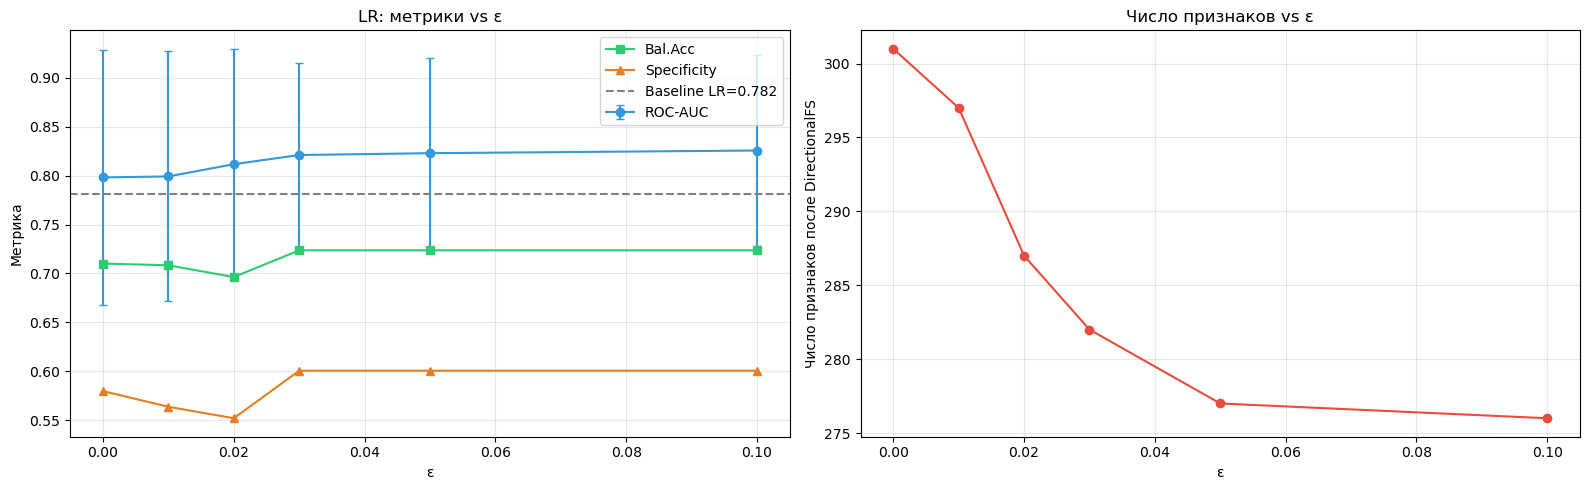

In [93]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
eps_arr = list(sweep_results.keys())
auc_vals = [sweep_results[e]['roc_auc'][0] for e in eps_arr]
auc_std  = [sweep_results[e]['roc_auc'][1] for e in eps_arr]
bac_vals = [sweep_results[e]['balanced_accuracy'][0] for e in eps_arr]
spec_vals = [sweep_results[e]['specificity'][0] for e in eps_arr]
n_feats  = [sweep_results[e]['n_after_direct'] for e in eps_arr]

axes[0].errorbar(eps_arr, auc_vals, yerr=auc_std, marker='o', color='#3498db', label='ROC-AUC', capsize=3)
axes[0].plot(eps_arr, bac_vals, marker='s', color='#2ecc71', label='Bal.Acc')
axes[0].plot(eps_arr, spec_vals, marker='^', color='#e67e22', label='Specificity')
base_auc_lr = res_baseline['LR']['roc_auc'][0]
axes[0].axhline(base_auc_lr, color='gray', ls='--', lw=1.5, label=f'Baseline LR={base_auc_lr:.3f}')
axes[0].set_xlabel('ε'); axes[0].set_ylabel('Метрика')
axes[0].set_title('LR: метрики vs ε'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(eps_arr, n_feats, marker='o', color='#e74c3c')
axes[1].set_xlabel('ε'); axes[1].set_ylabel('Число признаков после DirectionalFS')
axes[1].set_title('Число признаков vs ε'); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 20. Сводные результаты

,Конфигурация,Лучший AUC
11,19. Minimal,0.865
10,19. Directional (ε=0.02),0.863
7,11. 8. Геом+Дин+Углы + ex_dur + ex_dur,0.860
9,17. SMOTE k=5 (лучший),0.857
1,6. Динамика,0.802
4,9. Все dist_,0.792
3,8. Геом + Дин + Углы,0.788
6,10. dist_ + площади,0.768
2,7. Геом + Динамика,0.747
8,"16. UMAP-20 (лучший, 8. Геом+Дин+Углы + ex_dur)",0.697


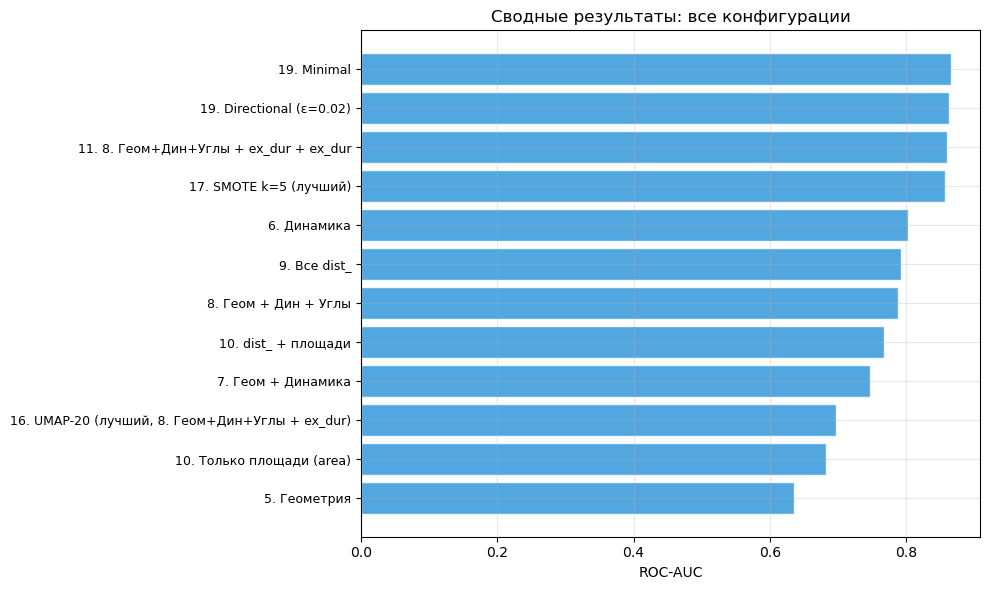

In [95]:
def best_auc(res):
    return max(res[m]['roc_auc'][0] for m in model_names)

summary_rows = [
    {'Конфигурация': '5. Геометрия',                       'Лучший AUC': f'{best_auc(res_no):.3f}'},
    {'Конфигурация': '6. Динамика',                        'Лучший AUC': f'{best_auc(res_dyn):.3f}'},
    {'Конфигурация': '7. Геом + Динамика',                 'Лучший AUC': f'{best_auc(res_geo_dyn):.3f}'},
    {'Конфигурация': '8. Геом + Дин + Углы',               'Лучший AUC': f'{best_auc(res_geo_dyn_ang):.3f}'},
    {'Конфигурация': '9. Все dist_',                       'Лучший AUC': f'{best_auc(res_all):.3f}'},
    {'Конфигурация': '10. Только площади (area)',            'Лучший AUC': f'{best_auc(res_area):.3f}'},
    {'Конфигурация': '10. dist_ + площади',                  'Лучший AUC': f'{best_auc(res_area_all):.3f}'},
    {'Конфигурация': f'11. {best_feat_label} + ex_dur',    'Лучший AUC': f'{max(best_auc(res_dur[k]) for k in configs_for_dur):.3f}'},
    {'Конфигурация': f'16. UMAP-{nc_b} (лучший, {best_feat_label})',  'Лучший AUC': f'{best_umap_auc:.3f}'},
    {'Конфигурация': f'17. SMOTE k={k_b} (лучший)',        'Лучший AUC': f'{best_auc_smote:.3f}'},
    {'Конфигурация': '19. Directional (ε=0.02)',           'Лучший AUC': f'{best_auc(res_directional):.3f}'},
    {'Конфигурация': '19. Minimal',                        'Лучший AUC': f'{best_auc(res_minimal):.3f}'},
]
sum_df = pd.DataFrame(summary_rows)
sum_df['Лучший AUC (float)'] = sum_df['Лучший AUC'].astype(float)
sum_df = sum_df.sort_values('Лучший AUC (float)', ascending=False).drop(columns=['Лучший AUC (float)'])
display(sum_df)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(len(sum_df)), sum_df['Лучший AUC'].astype(float),
        color='#3498db', alpha=0.85, edgecolor='white')
ax.set_yticks(range(len(sum_df)))
ax.set_yticklabels(sum_df['Конфигурация'].values, fontsize=13)
ax.invert_yaxis()
ax.set_xlabel('ROC-AUC'); ax.set_title('Сводные результаты: все конфигурации')
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 21. Отбор признаков стандартными методами sklearn

Сравниваются три метода из `sklearn.feature_selection` с лучшей конфигурацией Блока 2:
- **SelectKBest(f_classif, k)** — univariate F-тест, top-k признаков.
- **SelectFromModel(L1-LogReg)** — L1-регуляризация, зануляет неинформативные коэффициенты.
- **RFE(LogReg, n=20)** — recursive feature elimination.

Фильтрация per-fold внутри Pipeline — без утечки тест-фолда.

In [97]:
from sklearn.feature_selection import SelectKBest, f_classif, SelectFromModel, RFE

def run_with_selector(selector, X=None, y_=None, groups_=None):
    if X is None: X, y_, groups_ = X_best, y, groups
    cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    models = build_models(y_); res = {}
    for name, model in models.items():
        pipe = Pipeline([
            ('corr',   CorrelationFilter(threshold=0.95)),
            ('scaler', StandardScaler()),
            ('select', clone(selector) if selector is not None else 'passthrough'),
            ('model',  clone(model)),
        ])
        cvr = cross_validate(pipe, X, y_, groups=groups_, cv=cv,
                             scoring=scoring, return_train_score=False)
        res[name] = {k: (np.mean(cvr[f'test_{k}']), np.std(cvr[f'test_{k}'])) for k in scoring}
    return res

print('Функция определена.')

Функция определена.


In [98]:
selector_results = {'Baseline (без отбора)': best_res}

for k in [10, 20, 50, 100]:
    print(f'>>> SelectKBest k={k}')
    selector_results[f'SelectKBest k={k}'] = run_with_selector(SelectKBest(f_classif, k=k))

print('>>> SelectFromModel (L1-LogReg)')
l1_est = LogisticRegression(penalty='l1', solver='saga', C=0.1, max_iter=5000,
                             class_weight='balanced', random_state=RANDOM_STATE)
selector_results['SelectFromModel L1'] = run_with_selector(SelectFromModel(l1_est))

print('>>> RFE(LogReg, n=20)')
rfe_est = LogisticRegression(max_iter=5000, class_weight='balanced', random_state=RANDOM_STATE)
selector_results['RFE n=20'] = run_with_selector(RFE(rfe_est, n_features_to_select=20))
print('Готово.')

>>> SelectKBest k=10
>>> SelectKBest k=20
>>> SelectKBest k=50
>>> SelectKBest k=100
>>> SelectFromModel (L1-LogReg)
>>> RFE(LogReg, n=20)
Готово.


In [99]:
rows = []
for conf_name, res in selector_results.items():
    bm = max(res, key=lambda m: res[m]['roc_auc'][0])
    r  = res[bm]
    rows.append({'Configuration': conf_name, 'Best Model': bm,
        'ROC-AUC': f'{r["roc_auc"][0]:.3f}±{r["roc_auc"][1]:.3f}',
        'Bal.Acc': f'{r["balanced_accuracy"][0]:.3f}±{r["balanced_accuracy"][1]:.3f}',
        'Sens':    f'{r["sensitivity"][0]:.3f}',
        'Spec':    f'{r["specificity"][0]:.3f}',
    })
sel_summary_df = pd.DataFrame(rows)
display(sel_summary_df)

,Configuration,Best Model,ROC-AUC,Bal.Acc,Sens,Spec
0,Baseline (без отбора),XGB,0.860±0.057,0.784±0.045,0.879,0.690
1,SelectKBest k=10,LR,0.856±0.082,0.806±0.058,0.789,0.822
2,SelectKBest k=20,LR,0.851±0.066,0.776±0.074,0.815,0.737
3,SelectKBest k=50,XGB,0.851±0.046,0.760±0.048,0.879,0.641
4,SelectKBest k=100,XGB,0.836±0.063,0.763±0.079,0.891,0.634
5,SelectFromModel L1,XGB,0.849±0.054,0.787±0.066,0.860,0.714
6,RFE n=20,RF,0.856±0.068,0.723±0.035,0.904,0.542


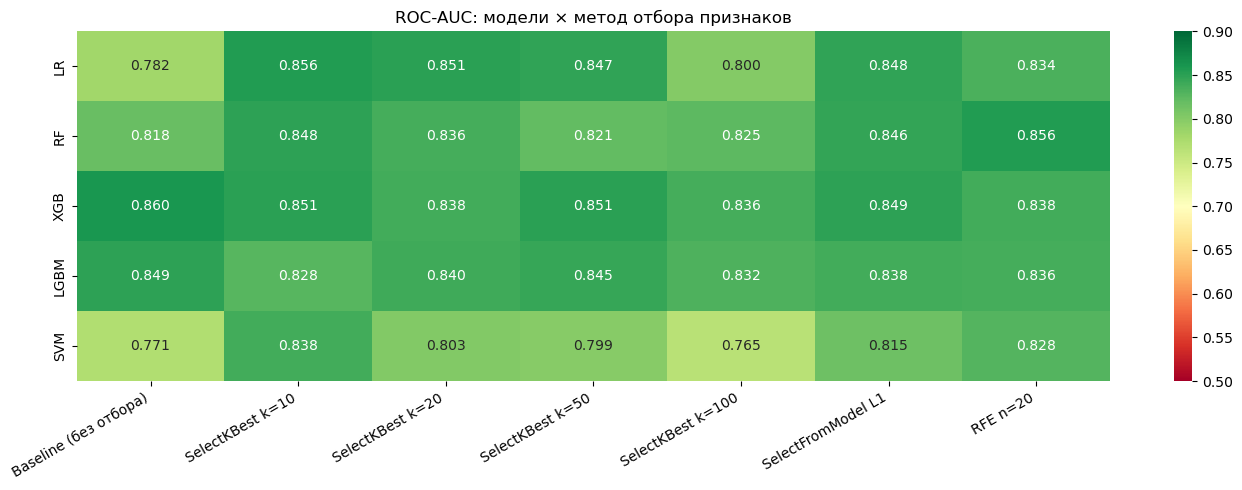

In [100]:
conf_names = list(selector_results.keys())
hm_sel = np.zeros((len(model_names), len(conf_names)))
for i, mn in enumerate(model_names):
    for j, cn in enumerate(conf_names):
        hm_sel[i,j] = selector_results[cn][mn]['roc_auc'][0]
fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(hm_sel, xticklabels=conf_names, yticklabels=model_names,
            annot=True, fmt='.3f', cmap='RdYlGn', vmin=0.5, vmax=0.9, ax=ax)
ax.set_title('ROC-AUC: модели × метод отбора признаков')
plt.xticks(rotation=30, ha='right')
plt.tight_layout(); plt.show()

### 21.1 Зависимость качества от числа отобранных признаков

Прогон SelectKBest по сетке `k ∈ {5, 10, 15, 20, 30, 50, 75, 100}` показывает,  
где кривая качества выходит на плато — минимальное достаточное число признаков.

  k=  5... лучший AUC = 0.868
  k= 10... лучший AUC = 0.856
  k= 15... лучший AUC = 0.843
  k= 20... лучший AUC = 0.851
  k= 30... лучший AUC = 0.857
  k= 50... лучший AUC = 0.851
  k= 75... лучший AUC = 0.848
  k=100... лучший AUC = 0.836


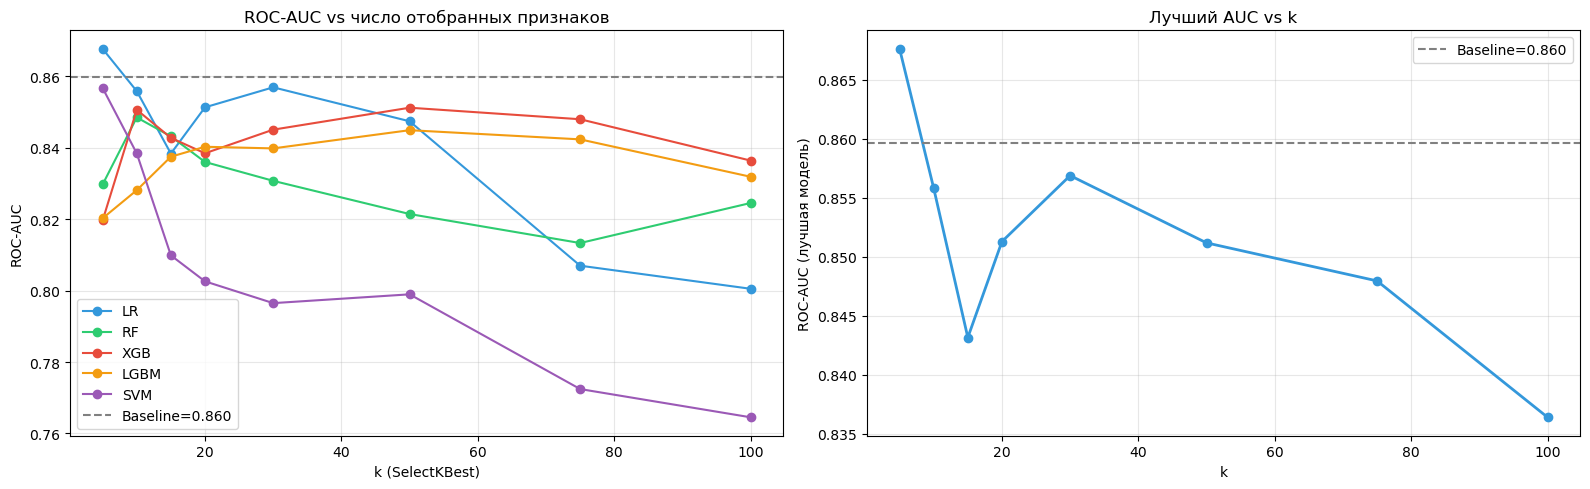

In [102]:
k_grid = [5, 10, 15, 20, 30, 50, 75, 100]
k_sweep_results = {}
for k in k_grid:
    print(f'  k={k:3d}...', end=' ')
    r_k = run_with_selector(SelectKBest(f_classif, k=k))
    k_sweep_results[k] = r_k
    best_k_auc = max(r_k[m]['roc_auc'][0] for m in model_names)
    print(f'лучший AUC = {best_k_auc:.3f}')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for mn in model_names:
    vals = [k_sweep_results[k][mn]['roc_auc'][0] for k in k_grid]
    axes[0].plot(k_grid, vals, 'o-', lw=1.5, label=mn, color=colors_m[mn])
base_best = max(best_res[m]['roc_auc'][0] for m in model_names)
axes[0].axhline(base_best, color='gray', ls='--', lw=1.5, label=f'Baseline={base_best:.3f}')
axes[0].set_xlabel('k (SelectKBest)'); axes[0].set_ylabel('ROC-AUC')
axes[0].set_title('ROC-AUC vs число отобранных признаков'); axes[0].legend(); axes[0].grid(alpha=0.3)

best_per_k = [max(k_sweep_results[k][m]['roc_auc'][0] for m in model_names) for k in k_grid]
axes[1].plot(k_grid, best_per_k, 'o-', lw=2, color='#3498db')
axes[1].axhline(base_best, color='gray', ls='--', lw=1.5, label=f'Baseline={base_best:.3f}')
axes[1].set_xlabel('k'); axes[1].set_ylabel('ROC-AUC (лучшая модель)')
axes[1].set_title('Лучший AUC vs k'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

### 21.2 Выводы раздела 21

- Сравнение с `SelectKBest`, `SelectFromModel` (L1) и `RFE` показывает, работает ли  
  жёсткое ограничение признакового пространства лучше корреляционной фильтрации.
- Learning curve по `k` выявляет минимально достаточное число признаков:  
  выход на плато означает, что часть фич избыточна.
- Отбор per-fold внутри Pipeline исключает утечку — оценка методологически честная.

## 22. Nested Cross-Validation — финальная оценка

Nested CV даёт несмещённую оценку качества модели с одновременным подбором гиперпараметров.

- **Внешний цикл**: `StratifiedGroupKFold(n_splits=5)` — пациент не попадает в train и test одновременно.
- **Внутренний цикл**: `GridSearchCV` с `StratifiedKFold(n_splits=3)` — поиск лучших гиперпараметров на train-части каждого внешнего фолда.

Конфигурация признаков: победитель Block 2 (`best_feat_label`).

In [105]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

param_grids = {
    'LR':   {'model__C': [0.01, 0.1, 1, 10]},
    'RF':   {'model__n_estimators': [100, 300], 'model__max_depth': [None, 5, 10]},
    'XGB':  {'model__learning_rate': [0.05, 0.1, 0.2],
              'model__max_depth': [3, 5], 'model__n_estimators': [100, 200]},
    'LGBM': {'model__learning_rate': [0.05, 0.1],
              'model__num_leaves': [31, 63], 'model__n_estimators': [100, 200]},
    'SVM':  {'model__C': [0.1, 1, 10]},
}

outer_cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

nested_results_wide = {}
for mn, model in build_models(y).items():
    pipe = Pipeline([
        ('corr',   CorrelationFilter(threshold=0.95)),
        ('scaler', StandardScaler()),
        ('model',  clone(model)),
    ])
    gs = GridSearchCV(pipe, param_grids[mn], cv=inner_cv,
                      scoring='roc_auc', n_jobs=-1, refit=True)
    outer_aucs = []
    for tr_idx, te_idx in outer_cv.split(X_best, y, groups):
        X_tr, y_tr = X_best.iloc[tr_idx], y.iloc[tr_idx]
        X_te, y_te = X_best.iloc[te_idx], y.iloc[te_idx]
        gs.fit(X_tr, y_tr)
        prob = gs.best_estimator_.predict_proba(X_te)[:, 1]
        outer_aucs.append(roc_auc_score(y_te, prob))
    nested_results_wide[mn] = {
        'aucs': outer_aucs,
        'mean': round(float(np.mean(outer_aucs)), 4),
        'std':  round(float(np.std(outer_aucs)),  4),
    }
    print(f'{mn}: AUC = {np.mean(outer_aucs):.3f} ± {np.std(outer_aucs):.3f}')

LR: AUC = 0.774 ± 0.130
RF: AUC = 0.814 ± 0.082
XGB: AUC = 0.855 ± 0.064
LGBM: AUC = 0.847 ± 0.048
SVM: AUC = 0.761 ± 0.060


,Simple CV AUC,Nested CV AUC,Смещение
Модель,,,
LR,0.782,0.774 ± 0.131,-0.008
RF,0.818,0.814 ± 0.082,-0.004
XGB,0.860,0.855 ± 0.064,-0.005
LGBM,0.849,0.848 ± 0.048,-0.001
SVM,0.771,0.761 ± 0.060,-0.010


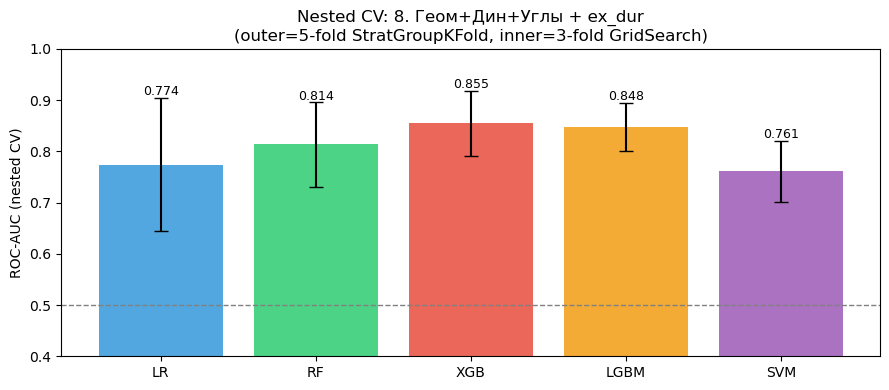


Лучшая модель (nested CV): XGB — AUC=0.855 ± 0.064


In [106]:
# Таблица сравнения: простая CV vs nested CV
nested_rows_w = []
for mn in model_names:
    simple_auc = best_res[mn]['roc_auc'][0]
    n = nested_results_wide[mn]
    nested_rows_w.append({
        'Модель':        mn,
        'Simple CV AUC': f'{simple_auc:.3f}',
        'Nested CV AUC': f'{n["mean"]:.3f} ± {n["std"]:.3f}',
        'Смещение':      f'{n["mean"] - simple_auc:+.3f}',
    })
nested_df_w = pd.DataFrame(nested_rows_w).set_index('Модель')
display(nested_df_w)

# Barplot
best_nested_w = max(nested_results_wide, key=lambda m: nested_results_wide[m]['mean'])
colors_m = {'LR':'#3498db','RF':'#2ecc71','XGB':'#e74c3c','LGBM':'#f39c12','SVM':'#9b59b6'}
fig, ax = plt.subplots(figsize=(9, 4))
means = [nested_results_wide[m]['mean'] for m in model_names]
stds  = [nested_results_wide[m]['std']  for m in model_names]
colors_bar = [colors_m[m] for m in model_names]
ax.bar(model_names, means, yerr=stds, color=colors_bar, alpha=0.85,
       capsize=5, error_kw={'linewidth': 1.5})
ax.axhline(0.5, color='gray', lw=1, ls='--')
for i, (m, v, s) in enumerate(zip(model_names, means, stds)):
    ax.text(i, v + s + 0.005, f'{v:.3f}', ha='center', fontsize=13)
ax.set_ylabel('ROC-AUC (nested CV)')
ax.set_title(f'Nested CV: {best_feat_label}\n(outer=5-fold StratGroupKFold, inner=3-fold GridSearch)')
ax.set_ylim(0.4, 1.0)
plt.tight_layout(); plt.show()
print(f'\nЛучшая модель (nested CV): {best_nested_w} — AUC={nested_results_wide[best_nested_w]["mean"]:.3f} ± {nested_results_wide[best_nested_w]["std"]:.3f}')

## 23. Проверка устойчивости: только первая попытка (r = 1)

Среднее число retake: PD = 1.28, Healthy = 3.67.  
Потенциальный confounding: модель могла выучить «много retake → Healthy».

Проверка: запускаем лучшую конфигурацию Block 2 **только** на наблюдениях с `r = 1`.  
Если AUC сохраняется — retake-confound отсутствует и результаты надёжны.


In [108]:
# Фильтрация: только первая попытка
df_r1 = df[df['r'] == 'r0'].copy()
n_pd_r1 = df_r1[df_r1.label == 1]['id'].nunique()
n_hc_r1 = df_r1[df_r1.label == 0]['id'].nunique()
print(f'r=1: {df_r1["id"].nunique()} пациентов ({n_pd_r1} PD / {n_hc_r1} Healthy)')
print(f'     наблюдений: {len(df_r1)}')
print(f'Лучшая конфигурация Block 2: {best_feat_label}  ({len(best_feat)} признаков)')
print()

# Лучшая конфигурация Block 2 на r=1 данных
feat_r1 = [c for c in best_feat if c in df_r1.columns]
X_r1 = df_r1[feat_r1]
y_r1 = df_r1['label']
g_r1 = df_r1['id']
print(f'Признаков: {len(feat_r1)}, наблюдений: {X_r1.shape[0]}')
print()

res_r1 = run_all(X_r1, y_r1, g_r1)

# Сравниваем с полным датасетом
r1_rows = []
for mn in model_names:
    full_auc = best_res[mn]['roc_auc'][0]
    r1_auc   = res_r1[mn]['roc_auc'][0]
    r1_rows.append({
        'Модель':           mn,
        'AUC (все retake)':  f'{full_auc:.3f}',
        'AUC (r=1 only)':    f'{r1_auc:.3f}',
        'Δ':                 f'{r1_auc - full_auc:+.3f}',
        'Bal.Acc (r=1)':     f'{res_r1[mn]["balanced_accuracy"][0]:.3f}',
    })

r1_df = pd.DataFrame(r1_rows).set_index('Модель')
display(r1_df.style.set_caption(f'Устойчивость к r=1 — {best_feat_label}'))

best_r1_mn   = max(res_r1,   key=lambda m: res_r1[m]['roc_auc'][0])
best_full_mn = max(best_res, key=lambda m: best_res[m]['roc_auc'][0])
auc_r1_val   = res_r1[best_r1_mn]['roc_auc'][0]
auc_full_val = best_res[best_full_mn]['roc_auc'][0]
diff = auc_r1_val - auc_full_val

print(f'Лучший AUC (все retake): {auc_full_val:.3f} ({best_full_mn})')
print(f'Лучший AUC (r=1 only):   {auc_r1_val:.3f} ({best_r1_mn})')
print(f'Δ = {diff:+.3f}')
print()
if abs(diff) < 0.05:
    print('Вывод: результаты стабильны — retake-confound отсутствует.')
else:
    print('Внимание: значительное расхождение — retake может быть confounding-фактором.')


r=1: 150 пациентов (123 PD / 27 Healthy)
     наблюдений: 150
Лучшая конфигурация Block 2: 8. Геом+Дин+Углы + ex_dur  (326 признаков)

Признаков: 326, наблюдений: 150



,AUC (все retake),AUC (r=1 only),Δ,Bal.Acc (r=1)
Модель,,,,
LR,0.782,0.754,-0.027,0.610
RF,0.818,0.732,-0.086,0.549
XGB,0.860,0.814,-0.046,0.704
LGBM,0.849,0.803,-0.046,0.691
SVM,0.771,0.675,-0.096,0.602


Лучший AUC (все retake): 0.860 (XGB)
Лучший AUC (r=1 only):   0.814 (XGB)
Δ = -0.046

Вывод: результаты стабильны — retake-confound отсутствует.
